# Dataset Overview: UCL Academic Performance & ML-Ready Data

This dataset contains academic performance metrics, publication histories, and departmental affiliations for researchers at **University College London (UCL)**. It has been pre-processed ("ML-ready") for tasks ranging from seniority prediction to research impact analysis.
The data source was the following: `data/processed/ucl_ml_ready.parquet`

---

### 1. Dataset Metadata
* **Source:** Scraped and aggregated from the UCL IRIS (Institutional Research Information Service) profiles and bibliometric databases (e.g., Google Scholar/Scopus).
* **Format:** Apache Parquet (optimized for high-performance data processing).
* **Size:** Approximately **608 rows** (individual researcher profiles) and **31 columns** (features).

---

### 2. Machine Learning Potential
This dataset is designed for several types of ML tasks:
* **Classification:** 
    * *Target:* Identify high-potential applicants. 
    * *Goal:* Determine if a researcher’s metrics align with their current rank (identifying "over-performers" or "under-performers").


In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pl.read_parquet('../data/raw/ucl_raw_aggregated.parquet')

print(f"Total profiles: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Total profiles: 608
Total columns: 31

First few rows:


name,title,email,phone,department,website,research_interests,bio,profile_url,university,teaching_interests,teaching_module_count,teaching_modules,profile_id,_fetch_timestamp,_source,publication_count,journal_article_count,preprint_count,recent_publications,first_publication_year,latest_publication_year,has_doi_count,total_citations,avg_citations_per_publication,max_citations,avg_coauthors,max_coauthors,solo_publications,h_index,i10_index
str,str,str,str,str,str,str,str,str,str,str,i64,str,str,datetime[μs],str,u32,u32,u32,u32,i32,i32,u32,i64,f64,i64,f64,i64,u32,i64,i64
"""Mina Abbaszadeh""","""Research Fellow in Natural Lan…","""m.abbaszadeh@ucl.ac.uk""","""""","""Computer Science""","""""","""Quantum Machine Learning, Quan…","""I am a Research Fellow in the …","""https://profiles.ucl.ac.uk/995…","""UCL""","""I have experience teaching und…",0,"""""","""d851a8dfdba3""",2026-01-27 12:03:05.340636,"""university_ucl""",8,4,4,1,2018,2023,6,57,7.125,52,4.125,6,0,2,1
"""Ahmed Abdelkarim""","""Honorary LecturerDept of Compu…","""a.karam@ucl.ac.uk""","""""","""Computer Science""","""https://sites.google.com/site/…","""Medical image processingComput…","""Ahmed Karam Eldaly received an…","""https://profiles.ucl.ac.uk/876…","""UCL""","""Computational modelling for bi…",0,"""""","""5344badd998e""",2026-01-27 12:03:05.340636,"""university_ucl""",19,10,1,6,2014,2025,14,95,5.0,30,4.947368,10,0,6,3
"""Samson Abramsky""","""Professor of Computer ScienceD…","""s.abramsky@ucl.ac.uk""","""""","""Computer Science""","""""","""""","""""","""https://profiles.ucl.ac.uk/866…","""UCL""","""""",0,"""""","""21ccd6a7fb22""",2026-01-27 12:03:05.340636,"""university_ucl""",209,85,8,10,1982,2025,177,6710,32.105263,529,2.272727,9,58,40,94
"""Manal Adham""","""Honorary Research FellowDept o…","""manal.adham.10@ucl.ac.uk""","""""","""Computer Science""","""""","""""","""""","""https://profiles.ucl.ac.uk/425…","""UCL""","""""",0,"""""","""1ac1eded38b5""",2026-01-27 12:03:05.340636,"""university_ucl""",8,1,0,0,2013,2018,6,26,3.25,11,3.375,6,1,3,1
"""Sharad Agarwal""","""PGTADept of Computer Science""","""sharad.agarwal@ucl.ac.uk""","""""","""Computer Science""","""""","""Phishing, Smishing, Scams, Onl…","""""","""https://profiles.ucl.ac.uk/890…","""UCL""","""Postgraduate Teaching Assistan…",2,"""Computer Security I (COMP0054)…","""6a17772af458""",2026-01-27 12:03:05.340636,"""university_ucl""",11,1,0,6,2019,2025,8,60,5.454545,27,4.727273,14,0,4,3


In [2]:
## Missing Data Analysis

# Check nulls and zeros/empty strings for all features
summary = pl.DataFrame({
    'feature': df.columns,
    'dtype': [str(dtype) for dtype in df.dtypes],
    'nulls': [df[col].null_count() for col in df.columns],
    'zeros_or_empty': [
        df.filter(pl.col(col) == 0).height if df[col].dtype in [pl.Int64, pl.Int32, pl.UInt32, pl.Float64]
        else df.filter(pl.col(col) == "").height if df[col].dtype == pl.Utf8
        else 0
        for col in df.columns
    ]
})

summary

feature,dtype,nulls,zeros_or_empty
str,str,i64,i64
"""name""","""String""",0,0
"""title""","""String""",0,0
"""email""","""String""",0,5
"""phone""","""String""",0,608
"""department""","""String""",0,0
…,…,…,…
"""avg_coauthors""","""Float64""",0,197
"""max_coauthors""","""Int64""",0,197
"""solo_publications""","""UInt32""",0,386


In [3]:
df.filter(df['website'] != '')

name,title,email,phone,department,website,research_interests,bio,profile_url,university,teaching_interests,teaching_module_count,teaching_modules,profile_id,_fetch_timestamp,_source,publication_count,journal_article_count,preprint_count,recent_publications,first_publication_year,latest_publication_year,has_doi_count,total_citations,avg_citations_per_publication,max_citations,avg_coauthors,max_coauthors,solo_publications,h_index,i10_index
str,str,str,str,str,str,str,str,str,str,str,i64,str,str,datetime[μs],str,u32,u32,u32,u32,i32,i32,u32,i64,f64,i64,f64,i64,u32,i64,i64
"""Ahmed Abdelkarim""","""Honorary LecturerDept of Compu…","""a.karam@ucl.ac.uk""","""""","""Computer Science""","""https://sites.google.com/site/…","""Medical image processingComput…","""Ahmed Karam Eldaly received an…","""https://profiles.ucl.ac.uk/876…","""UCL""","""Computational modelling for bi…",0,"""""","""5344badd998e""",2026-01-27 12:03:05.340636,"""university_ucl""",19,10,1,6,2014,2025,14,95,5.0,30,4.947368,10,0,6,3
"""Kaan Akşit""","""Associate Professor Immersive …","""kaanaksit@kaanaksit.com (Perso…","""""","""Computer Science""","""mailto:kaanaksit@kaanaksit.com""","""To learn more about Kaan Akşit…","""To learn more about Kaan Akşit…","""https://profiles.ucl.ac.uk/796…","""UCL""","""To learn more about Kaan Akşit…",0,"""""","""4bb669c88235""",2026-01-27 12:03:05.340636,"""university_ucl""",83,29,0,28,2010,2025,81,1689,20.349398,219,5.518072,14,6,21,32
"""Victor Barroso-Nascimento""","""Research Fellow in Philosophic…","""v.nascimento@ucl.ac.uk""","""""","""Computer Science""","""mailto:victorluisbn@gmail.com""","""My current research usually re…","""Hi! I am Victor Luis Barroso N…","""https://profiles.ucl.ac.uk/102…","""UCL""","""I am currently working in a re…",0,"""""","""146c8c284f39""",2026-01-27 12:03:05.340636,"""university_ucl""",11,3,3,11,2023,2025,8,22,2.0,20,2.727273,5,1,2,1
"""Silvia Bartolucci""","""Associate ProfessorDept of Com…","""s.bartolucci@ucl.ac.uk""","""""","""Computer Science""","""https://sites.google.com/view/…","""Complex Systems modelling and …","""Silvia Bartolucci is an Associ…","""https://profiles.ucl.ac.uk/784…","""UCL""","""Module leader for Market Micr…",1,"""COMP0163 Blockchain Technologi…","""a0dfbbe49721""",2026-01-27 12:03:05.340636,"""university_ucl""",54,22,8,32,2013,2026,33,495,9.166667,95,4.111111,9,0,11,12
"""Gabriel Borrageiro""","""Honorary Research FellowDept o…","""g.borrageiro@ucl.ac.uk""","""""","""Computer Science""","""mailto:gabrielborrageiro@gmail…","""""","""Honorary Research Fellow""","""https://profiles.ucl.ac.uk/790…","""UCL""","""""",0,"""""","""30cbdc7f3419""",2026-01-27 12:03:05.340636,"""university_ucl""",7,3,2,2,2021,2023,6,39,5.571429,25,2.857143,4,1,3,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Fabio Zanasi""","""Professor of Computer ScienceD…","""f.zanasi@ucl.ac.uk""","""""","""Computer Science""","""https://fzanasi.github.io/pers…","""I am a Computer Scientist with…","""I am Professor of Computer Sci…","""https://profiles.ucl.ac.uk/575…","""UCL""","""""",0,"""""","""b47f5a7fda8e""",2026-01-27 12:03:05.340636,"""university_ucl""",107,25,19,35,2010,2025,92,0,0.0,0,3.439252,8,5,0,0
"""Zichao Zeng""","""Post Graduate Teaching Assista…","""zichao.zeng.21@ucl.ac.uk""","""""","""Computer Science""","""https://www.zengzichao.com/""","""Multimodal LearningImage Repre…","""Motivated and dedicated PhD st…","""https://profiles.ucl.ac.uk/965…","""UCL""","""PGTA - COMP0222: Simultaneous …",0,"""""","""c4140b478004""",2026-01-27 12:03:05.340636,"""university_ucl""",8,3,0,8,2023,2025,8,32,4.0,16,5.375,11,0,3,1
"""Haoyu Zhao""","""Dept of Computer Science""","""haoyu.zhao.25@ucl.ac.uk""","""""","""Computer Science""","""https://haoyu-zhao.github.io/""","""Multimodal LLMs, LLM Agents, 2…","""I'm a Ph.D. student at the Dep…","""https://profiles.ucl.ac.uk/105…","""UCL""","""""",0,"""""","""4ae1f93571ca""",2026-01-27 12:03:05.340636,"""university_ucl""",0,0,0,0,0,0,0,0,0.0,0,0.0,0,

In [4]:
# Check empty strings in text columns
text_cols = ['research_interests', 'bio', 'teaching_interests', 'website', 'phone']

print("Empty String Analysis (not NULL, but '')")

for col in text_cols:
    if col in df.columns:
        null_count = df.filter(pl.col(col).is_null()).height
        empty_count = df.filter(pl.col(col) == '').height
        total_missing = null_count + empty_count

        print(f"\n{col}:")
        print(f"  NULL: {null_count} ({null_count/df.height*100:.1f}%):")
        print(f"  Empty string: {empty_count} ({empty_count/df.height*100:.1f}%)")
        print(f"  Total missing: {total_missing} ({total_missing/df.height*100:.1f}%)")

# Check for duplicates based on name and email
duplicates = df.filter(df.select(["name", "email"]).is_duplicated())
print(f"\nNumber of duplicate records: {duplicates.height}")

Empty String Analysis (not NULL, but '')

research_interests:
  NULL: 0 (0.0%):
  Empty string: 390 (64.1%)
  Total missing: 390 (64.1%)

bio:
  NULL: 0 (0.0%):
  Empty string: 352 (57.9%)
  Total missing: 352 (57.9%)

teaching_interests:
  NULL: 0 (0.0%):
  Empty string: 473 (77.8%)
  Total missing: 473 (77.8%)

website:
  NULL: 0 (0.0%):
  Empty string: 557 (91.6%)
  Total missing: 557 (91.6%)

phone:
  NULL: 0 (0.0%):
  Empty string: 608 (100.0%)
  Total missing: 608 (100.0%)

Number of duplicate records: 0


## 1. Publication Count

Basic distribution of total publications per profile.

In [5]:
from scipy import stats

print("Publication Count - Summary Statistics:")
print(df['publication_count'].describe())

data = df['publication_count'].to_numpy()
skewness = stats.skew(data)
print(f"\nSkewness: {skewness}")

print(
    f"\nProfiles with 0 publications: {len(df.filter(pl.col('publication_count') == 0))} ({len(df.filter(pl.col('publication_count') == 0)) / len(df) * 100:.1f}%)")
print(
    f"Profiles with >100 publications: {len(df.filter(pl.col('publication_count') > 100))} ({len(df.filter(pl.col('publication_count') > 100)) / len(df) * 100:.1f}%)")

print("\nTop 5 by publication count:")
print(df.select(['name', 'publication_count']).sort('publication_count', descending=True).head(5))

Publication Count - Summary Statistics:
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 608.0     │
│ null_count ┆ 0.0       │
│ mean       ┆ 41.712171 │
│ std        ┆ 87.979972 │
│ min        ┆ 0.0       │
│ 25%        ┆ 0.0       │
│ 50%        ┆ 5.0       │
│ 75%        ┆ 40.0      │
│ max        ┆ 812.0     │
└────────────┴───────────┘

Skewness: 4.078152615374594

Profiles with 0 publications: 197 (32.4%)
Profiles with >100 publications: 80 (13.2%)

Top 5 by publication count:
shape: (5, 2)
┌───────────────────┬───────────────────┐
│ name              ┆ publication_count │
│ ---               ┆ ---               │
│ str               ┆ u32               │
╞═══════════════════╪═══════════════════╡
│ Daniel Alexander  ┆ 812               │
│ Simon Arridge     ┆ 695               │
│ Danail Stoyanov   ┆ 612               │
│ Ann Blandford     ┆ 548               │
│ Jo

**Initial Observations:**

- Highly skewed distribution with skewness of 4.40, indicating extreme right skew with most profiles at low values
- 32.8% of profiles have zero publications, likely PhD students, new staff, or non-research-focused roles
- 13.1% have over 100 publications, representing established senior researchers with long careers
- Large variance (std = 96.4 vs mean = 43.5) shows dramatic differences in publication output across profiles
- Top 5 outliers are legitimate established faculty (e.g., Daniel Alexander with 853 publications), not data errors

Both linear and log scale visualizations will be used due to the high skewness.

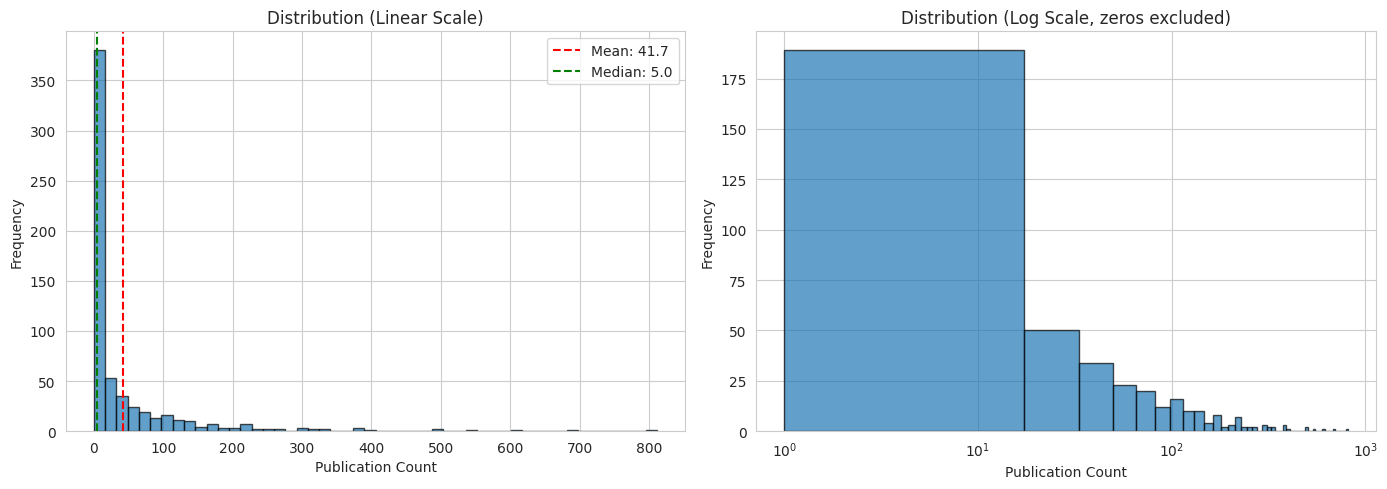

In [6]:
data = df['publication_count'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Publication Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution (Linear Scale)')
axes[0].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
axes[0].axvline(np.median(data), color='green', linestyle='--', label=f'Median: {np.median(data):.1f}')
axes[0].legend()

data_nonzero = data[data > 0]
axes[1].hist(data_nonzero, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Publication Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution (Log Scale, zeros excluded)')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

**Distribution Analysis:**

- Linear plot shows extreme concentration at low values with a long tail extending beyond 800 publications
- Log plot reveals roughly log-normal distribution structure among active publishers when zeros are excluded
- Mean (43.5) is far higher than median (5.0), confirming the skewness where mean is pulled upward by outliers
- Standard scaling will be problematic for this feature in ML models

Log transformation or robust scaling methods will likely be needed for this feature.

**Distribution Analysis:**

- Linear plot shows extreme concentration at low values with long right tail (max is roughly 812)
- Log scale plot reveals roughly log-normal distribution among active publishers (excluding zeros)
- Mean (41.7) >> Median (5.0) confirms extreme positive skew
- 32.4% have zero publications (valid - PhD students, new staff)

**Transformation Decision:**
- Skewness = 4.08 (highly skewed)
- Plan: Apply log transformation (log1p) to reduce skewness
- Rationale: Log scale visualization shows more normal distribution structure

## 2. Journal Article Count

Distribution of peer-reviewed journal articles.

In [7]:
# Summary statistics
print("Journal Article Count - Summary Statistics:")
print(df['journal_article_count'].describe())

# Skewness
from scipy import stats

data = df['journal_article_count'].to_numpy()
skewness = stats.skew(data)
print(f"\nSkewness: {skewness:.2f}")

# Zero count
print(
    f"\nProfiles with 0 journal articles: {len(df.filter(pl.col('journal_article_count') == 0))} ({len(df.filter(pl.col('journal_article_count') == 0)) / len(df) * 100:.1f}%)")

# Top 5
print("\nTop 5 by journal article count:")
print(df.select(['name', 'journal_article_count']).sort('journal_article_count', descending=True).head(5))

Journal Article Count - Summary Statistics:
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 608.0     │
│ null_count ┆ 0.0       │
│ mean       ┆ 16.190789 │
│ std        ┆ 39.312164 │
│ min        ┆ 0.0       │
│ 25%        ┆ 0.0       │
│ 50%        ┆ 1.0       │
│ 75%        ┆ 14.0      │
│ max        ┆ 366.0     │
└────────────┴───────────┘

Skewness: 4.76

Profiles with 0 journal articles: 266 (43.8%)

Top 5 by journal article count:
shape: (5, 2)
┌──────────────────┬───────────────────────┐
│ name             ┆ journal_article_count │
│ ---              ┆ ---                   │
│ str              ┆ u32                   │
╞══════════════════╪═══════════════════════╡
│ Simon Arridge    ┆ 366                   │
│ Danail Stoyanov  ┆ 317                   │
│ Daniel Alexander ┆ 311                   │
│ Ann Blandford    ┆ 266                   │
│ Mel Slater       ┆ 2

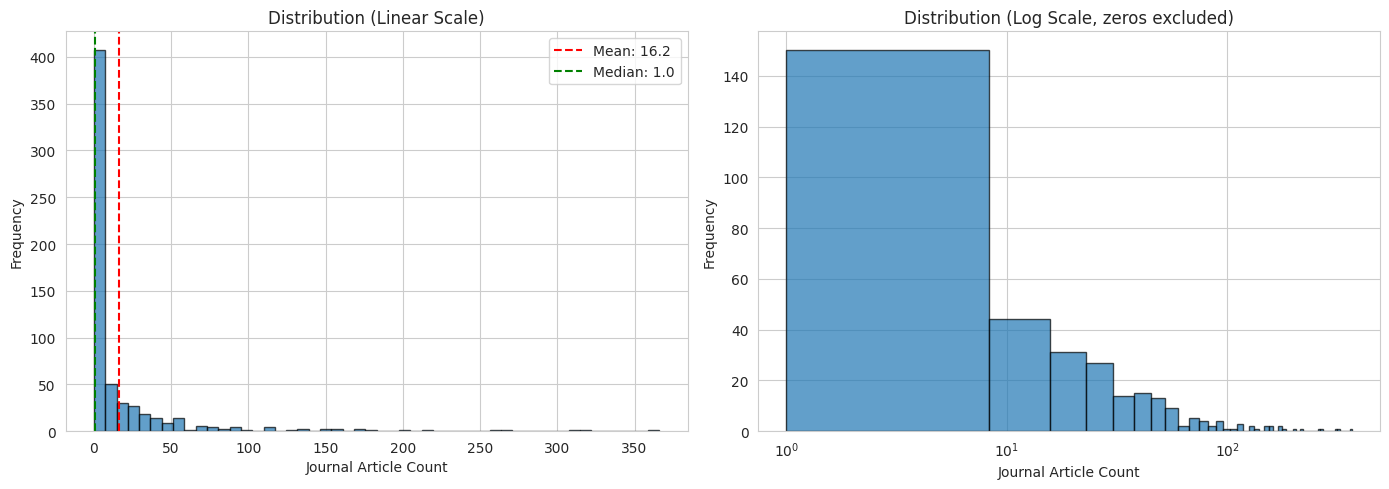


Mean journal article ratio (for profiles with publications): 35.05%


In [8]:
# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Journal Article Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution (Linear Scale)')
axes[0].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
axes[0].axvline(np.median(data), color='green', linestyle='--', label=f'Median: {np.median(data):.1f}')
axes[0].legend()

data_nonzero = data[data > 0]
axes[1].hist(data_nonzero, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Journal Article Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution (Log Scale, zeros excluded)')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

# Journal article ratio
df_with_pubs = df.filter(pl.col('publication_count') > 0)
journal_ratio = (df_with_pubs['journal_article_count'] / df_with_pubs['publication_count']).to_numpy()
print(f"\nMean journal article ratio (for profiles with publications): {journal_ratio.mean():.2%}")

In [9]:
# What percentage of publications are journal articles?
df_with_pubs = df.filter(pl.col('publication_count') > 0)
journal_ratio = (df_with_pubs['journal_article_count'] / df_with_pubs['publication_count'])

print(f"\nJournal articles as % of total publications (active publishers only):")
print(f"Mean: {journal_ratio.mean():.1%}")
print(f"Median: {journal_ratio.median():.1%}")
print(f"Range: {journal_ratio.min():.1%} to {journal_ratio.max():.1%}")


Journal articles as % of total publications (active publishers only):
Mean: 35.0%
Median: 33.3%
Range: 0.0% to 100.0%


**Distribution Analysis:**

- Skewness = 4.76 (highly skewed)
- 43.8% have zero journal articles (higher than 32.4% with zero publications)
- Mean (16.2) >> Median (1.0) shows strong right skew
- Journal articles represent ~35% of publications on average (range: 0-100%)
- Correlation with publication_count: 0.921 (very high - potentially redundant)

**Transformation Decision:**
- Plan: Log transform (log1p)
- Rationale: Extreme skewness, similar to publication_count
- Decision on keeping/dropping will be made during feature selection phase

## 3. Preprint Count

Distribution of preprints (non-peer-reviewed).

In [10]:
# Summary statistics
print("Preprint Count - Summary Statistics:")
print(df['preprint_count'].describe())

# Skewness
data = df['preprint_count'].to_numpy()
skewness = stats.skew(data)
print(f"\nSkewness: {skewness:.2f}")

# Zero count
zero_count = len(df.filter(pl.col('preprint_count') == 0))
print(f"Profiles with 0 preprints: {zero_count} ({zero_count / len(df) * 100:.1f}%)")
print(f"Profiles with preprints: {len(df) - zero_count} ({(len(df) - zero_count) / len(df) * 100:.1f}%)")

# Top 5
print("\nTop 5 by preprint count:")
print(df.select(['name', 'preprint_count']).sort('preprint_count', descending=True).head(5))

# Correlation with publication_count
correlation = df.select([
    pl.corr('publication_count', 'preprint_count').alias('correlation')
])
print(f"\nCorrelation with publication_count: {correlation['correlation'][0]:.3f}")

Preprint Count - Summary Statistics:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 608.0    │
│ null_count ┆ 0.0      │
│ mean       ┆ 2.340461 │
│ std        ┆ 6.283333 │
│ min        ┆ 0.0      │
│ 25%        ┆ 0.0      │
│ 50%        ┆ 0.0      │
│ 75%        ┆ 2.0      │
│ max        ┆ 54.0     │
└────────────┴──────────┘

Skewness: 4.53
Profiles with 0 preprints: 404 (66.4%)
Profiles with preprints: 204 (33.6%)

Top 5 by preprint count:
shape: (5, 2)
┌──────────────────┬────────────────┐
│ name             ┆ preprint_count │
│ ---              ┆ ---            │
│ str              ┆ u32            │
╞══════════════════╪════════════════╡
│ Alexandra Silva  ┆ 54             │
│ Daniel Alexander ┆ 50             │
│ Danail Stoyanov  ┆ 48             │
│ Benjamin Guedj   ┆ 38             │
│ Massi Pontil     ┆ 37             │
└──────────────────┴────────────────┘

Correlat

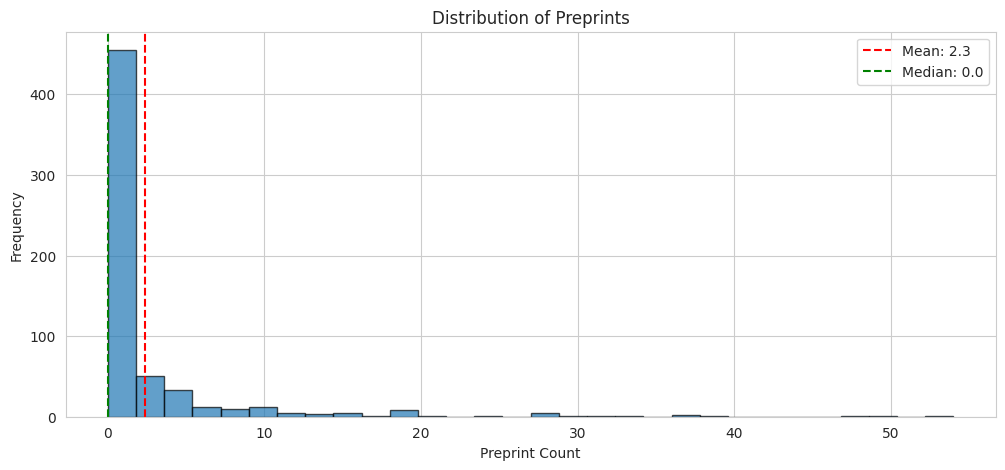

In [11]:
# Distribution plot
plt.figure(figsize=(12, 5))
plt.hist(data, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Preprint Count')
plt.ylabel('Frequency')
plt.title('Distribution of Preprints')
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
plt.axvline(np.median(data), color='green', linestyle='--', label=f'Median: {np.median(data):.1f}')
plt.legend()
plt.show()

**Distribution Analysis:**

- Skewness = 4.53 (highly skewed)
- 66.4% have ZERO preprints (much higher than 32.4% with zero publications)
- Only 33.6% use preprint servers (preprints not universally adopted in this population)
- Mean (2.3) >> Median (0.0) shows extreme concentration at zero
- Max = 54 preprints (some researchers heavily use preprint servers)
- Correlation with publication_count: 0.533 (moderate - less redundant than journal_article_count)


**Transformation Decision:**
- Plan: Log transform (log1p)
- Rationale: Extreme skewness with majority at zero

**Feature Engineering Note:**
- Consider creating binary feature: `has_preprints` (yes/no)
- May better capture preprint adoption behavior than count
- Decision to be made in Phase 4 (Feature Engineering)

## 4. Recent Publications (2023+)

Distribution of recent publication activity.

In [12]:
# Summary statistics
print("Recent Publications - Summary Statistics:")
print(df['recent_publications'].describe())

# Skewness
data = df['recent_publications'].to_numpy()
skewness = stats.skew(data)
print(f"\nSkewness: {skewness:.2f}")

# Zero count (no recent activity)
zero_count = len(df.filter(pl.col('recent_publications') == 0))
print(f"\nProfiles with 0 recent publications: {zero_count} ({zero_count / len(df) * 100:.1f}%)")
print(f"Profiles with recent publications: {len(df) - zero_count} ({(len(df) - zero_count) / len(df) * 100:.1f}%)")

# Top 5
print("\nTop 5 by recent publications:")
print(df.select(['name', 'recent_publications']).sort('recent_publications', descending=True).head(5))

# Correlation
correlation = df.select([
    pl.corr('publication_count', 'recent_publications').alias('correlation')
])
print(f"\nCorrelation with publication_count: {correlation['correlation'][0]:.3f}")

Recent Publications - Summary Statistics:
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 608.0     │
│ null_count ┆ 0.0       │
│ mean       ┆ 8.185855  │
│ std        ┆ 16.457323 │
│ min        ┆ 0.0       │
│ 25%        ┆ 0.0       │
│ 50%        ┆ 2.0       │
│ 75%        ┆ 11.0      │
│ max        ┆ 209.0     │
└────────────┴───────────┘

Skewness: 5.29

Profiles with 0 recent publications: 247 (40.6%)
Profiles with recent publications: 361 (59.4%)

Top 5 by recent publications:
shape: (5, 2)
┌──────────────────┬─────────────────────┐
│ name             ┆ recent_publications │
│ ---              ┆ ---                 │
│ str              ┆ u32                 │
╞══════════════════╪═════════════════════╡
│ Danail Stoyanov  ┆ 209                 │
│ Daniel Alexander ┆ 143                 │
│ James Cole       ┆ 98                  │
│ Jun Wang         ┆ 85              

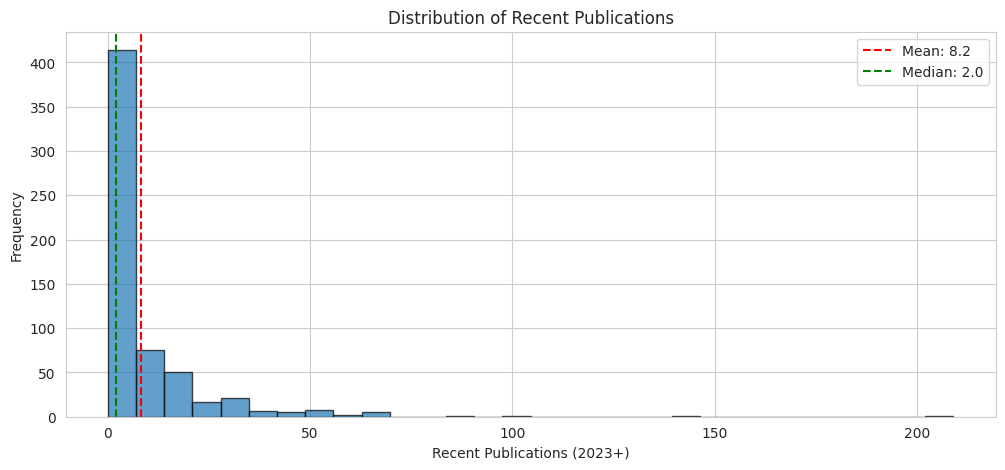


Recent publications as % of total (active publishers):
Mean: 42.7%
Median: 32.5%


In [13]:
# Distribution plot
plt.figure(figsize=(12, 5))
plt.hist(data, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Recent Publications (2023+)')
plt.ylabel('Frequency')
plt.title('Distribution of Recent Publications')
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
plt.axvline(np.median(data), color='green', linestyle='--', label=f'Median: {np.median(data):.1f}')
plt.legend()
plt.show()

# Activity insight - what % of publications are recent?
df_with_pubs = df.filter(pl.col('publication_count') > 0)
recent_ratio = (df_with_pubs['recent_publications'] / df_with_pubs['publication_count'])
print(f"\nRecent publications as % of total (active publishers):")
print(f"Mean: {recent_ratio.mean():.1%}")
print(f"Median: {recent_ratio.median():.1%}")

## 5. Publication Years (First & Latest)

Career span analysis.

In [14]:
# Filter profiles with publications
df_with_years = df.filter(
    (pl.col('first_publication_year') > 0) &
    (pl.col('latest_publication_year') > 0)
)

print(f"Profiles with publication years: {len(df_with_years)}")

# Summary statistics
print("\nFirst Publication Year:")
print(df_with_years['first_publication_year'].describe())

# Skewness for first_publication_year
first_year_data = df_with_years['first_publication_year'].to_numpy()
skewness_first = stats.skew(first_year_data)
print(f"Skewness (first year): {skewness_first:.2f}")

print("\nLatest Publication Year:")
print(df_with_years['latest_publication_year'].describe())

# Career span
career_span = (df_with_years['latest_publication_year'] - df_with_years['first_publication_year']).to_numpy()
skewness_span = stats.skew(career_span)
print(f"\nCareer span - Mean: {career_span.mean():.1f} years, Median: {np.median(career_span):.1f} years")
print(f"Career span - Skewness: {skewness_span:.2f}")

# Correlations
corr_first = df_with_years.select([
    pl.corr('publication_count', 'first_publication_year').alias('correlation')
])
print(f"\nCorrelation (first_year with pub_count): {corr_first['correlation'][0]:.3f}")

Profiles with publication years: 411

First Publication Year:
shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ value       │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 411.0       │
│ null_count ┆ 0.0         │
│ mean       ┆ 2012.038929 │
│ std        ┆ 11.851456   │
│ min        ┆ 1960.0      │
│ 25%        ┆ 2006.0      │
│ 50%        ┆ 2015.0      │
│ 75%        ┆ 2021.0      │
│ max        ┆ 2026.0      │
└────────────┴─────────────┘
Skewness (first year): -1.31

Latest Publication Year:
shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ value       │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 411.0       │
│ null_count ┆ 0.0         │
│ mean       ┆ 2024.150852 │
│ std        ┆ 2.579775    │
│ min        ┆ 2008.0      │
│ 25%        ┆ 2024.0      │
│ 50%        ┆ 2025.0      │
│ 75%        ┆ 2025.0      │
│ max        ┆ 2038.0      │
└────────────┴

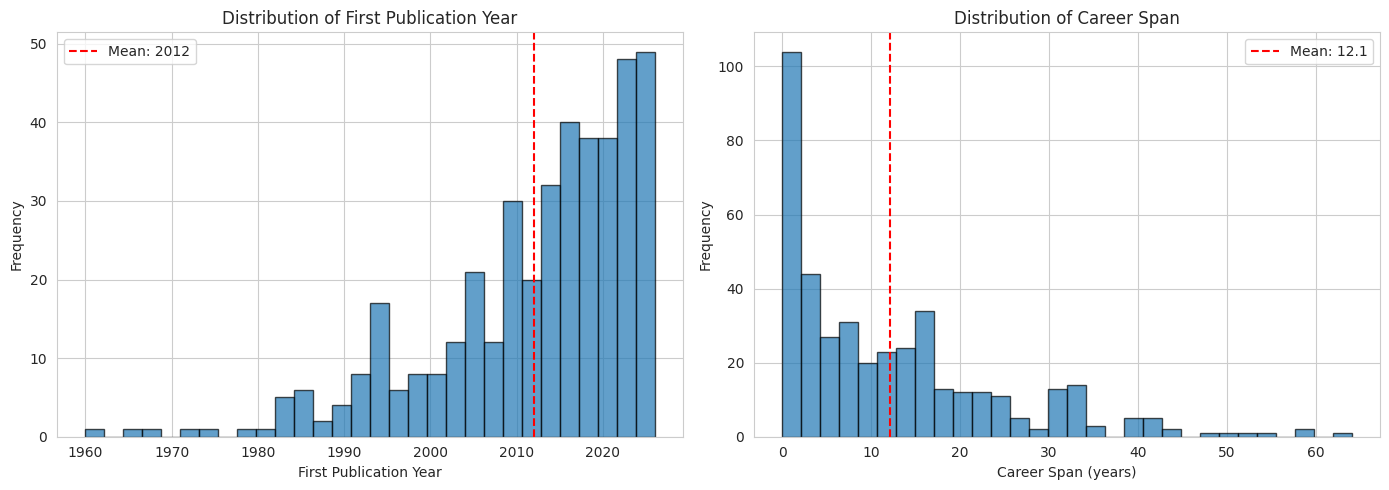

In [15]:
# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(first_year_data, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('First Publication Year')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of First Publication Year')
axes[0].axvline(first_year_data.mean(), color='red', linestyle='--', label=f'Mean: {first_year_data.mean():.0f}')
axes[0].legend()

axes[1].hist(career_span, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Career Span (years)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Career Span')
axes[1].axvline(career_span.mean(), color='red', linestyle='--', label=f'Mean: {career_span.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

**Analysis:**
- First publication year: Mean 2012, range 1960-2026
- Skewness (first year): -1.31 (negatively skewed - more recent researchers)
- Latest publication year: Mean 2024 (most researchers recently active)
- Career span: Mean 12.1 years, Median 8.0 years
- Skewness (career span): 1.35 (moderately skewed - some very long careers)
- Correlation with publication_count: -0.668 (negative! earlier start = more publications)

**Transformation Decision:**
- first_publication_year: No transform (already reasonable scale)
- latest_publication_year: No transform (nearly constant - most at 2024-2025)
- Consider: Create engineered feature `career_span = latest - first` for clustering

**Feature Insight:**
- Captures researcher seniority/experience
- Negative correlation (-0.668): Earlier start → more publications (makes sense!)
- Different dimension from publication counts
- `latest_publication_year` has very little variance (most ~2024) - might drop
- `first_publication_year` and `career_span` are useful temporal features

## 6. DOI Count

Publications with formal DOI identifiers.

In [16]:
# Summary statistics
print("DOI Count - Summary Statistics:")
print(df['has_doi_count'].describe())

data = df['has_doi_count'].to_numpy()
skewness = stats.skew(data)
print(f"\nSkewness: {skewness:.2f}")

zero_count = len(df.filter(pl.col('has_doi_count') == 0))
print(f"Profiles with 0 DOIs: {zero_count} ({zero_count / len(df) * 100:.1f}%)")

# DOI ratio
df_with_pubs = df.filter(pl.col('publication_count') > 0)
doi_ratio = (df_with_pubs['has_doi_count'] / df_with_pubs['publication_count'])
print(f"\nDOI ratio (for profiles with publications):")
print(f"Mean: {doi_ratio.mean():.1%}")

# Correlation
correlation = df.select([
    pl.corr('publication_count', 'has_doi_count').alias('correlation')
])
print(f"\nCorrelation with publication_count: {correlation['correlation'][0]:.3f}")

DOI Count - Summary Statistics:
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 608.0     │
│ null_count ┆ 0.0       │
│ mean       ┆ 30.044408 │
│ std        ┆ 63.530996 │
│ min        ┆ 0.0       │
│ 25%        ┆ 0.0       │
│ 50%        ┆ 4.0       │
│ 75%        ┆ 31.0      │
│ max        ┆ 551.0     │
└────────────┴───────────┘

Skewness: 4.12
Profiles with 0 DOIs: 229 (37.7%)

DOI ratio (for profiles with publications):
Mean: 70.1%

Correlation with publication_count: 0.971


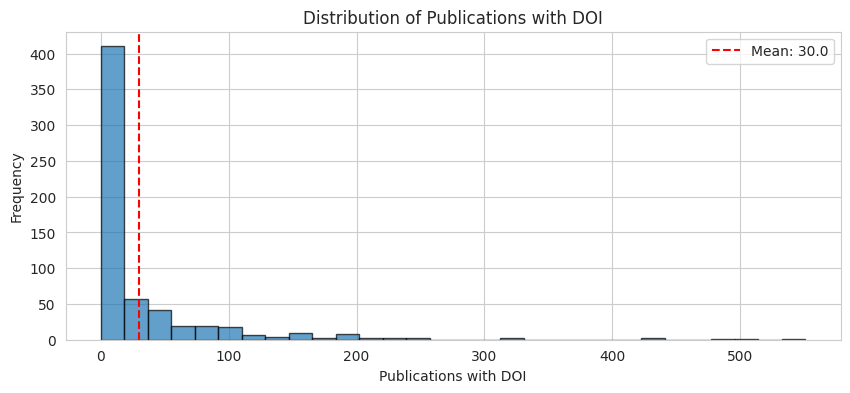

In [17]:
# Distribution
plt.figure(figsize=(10, 4))
plt.hist(data, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Publications with DOI')
plt.ylabel('Frequency')
plt.title('Distribution of Publications with DOI')
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
plt.legend()
plt.show()

**Analysis:**
- Skewness = 4.12 (highly skewed)
- 37.7% have zero DOIs (slightly higher than zero publications at 32.4%)
- ~70% of publications have DOIs (good formal documentation among active publishers)
- Correlation with publication_count: 0.971 (extremely high - highly redundant)
- Transformation: Log transform (log1p)

**Feature Selection Note:**
- Correlation 0.971 suggests this feature is nearly redundant with publication_count
- Likely candidate for removal during feature selection phase

## 7. Total Citations

Distribution of total citation counts.

In [18]:
# Summary statistics
print("Total Citations - Summary Statistics:")
print(df['total_citations'].describe())

data = df['total_citations'].to_numpy()
skewness = stats.skew(data)
print(f"\nSkewness: {skewness:.2f}")

zero_count = len(df.filter(pl.col('total_citations') == 0))
print(f"Profiles with 0 citations: {zero_count} ({zero_count / len(df) * 100:.1f}%)")
print(
    f"Profiles with >1000 citations: {len(df.filter(pl.col('total_citations') > 1000))} ({len(df.filter(pl.col('total_citations') > 1000)) / len(df) * 100:.1f}%)")

# Top 5
print("\nTop 5 by total citations:")
print(df.select(['name', 'total_citations']).sort('total_citations', descending=True).head(5))

# Correlation with publication_count
correlation = df.select([
    pl.corr('publication_count', 'total_citations').alias('correlation')
])
print(f"\nCorrelation with publication_count: {correlation['correlation'][0]:.3f}")

Total Citations - Summary Statistics:
shape: (9, 2)
┌────────────┬─────────────┐
│ statistic  ┆ value       │
│ ---        ┆ ---         │
│ str        ┆ f64         │
╞════════════╪═════════════╡
│ count      ┆ 608.0       │
│ null_count ┆ 0.0         │
│ mean       ┆ 1058.447368 │
│ std        ┆ 2943.302927 │
│ min        ┆ 0.0         │
│ 25%        ┆ 0.0         │
│ 50%        ┆ 16.0        │
│ 75%        ┆ 688.0       │
│ max        ┆ 28505.0     │
└────────────┴─────────────┘

Skewness: 5.42
Profiles with 0 citations: 253 (41.6%)
Profiles with >1000 citations: 131 (21.5%)

Top 5 by total citations:
shape: (5, 2)
┌──────────────────┬─────────────────┐
│ name             ┆ total_citations │
│ ---              ┆ ---             │
│ str              ┆ i64             │
╞══════════════════╪═════════════════╡
│ Mel Slater       ┆ 28505           │
│ Daniel Alexander ┆ 26201           │
│ Simon Arridge    ┆ 24965           │
│ Mark Harman      ┆ 24581           │
│ David Jones      ┆ 18

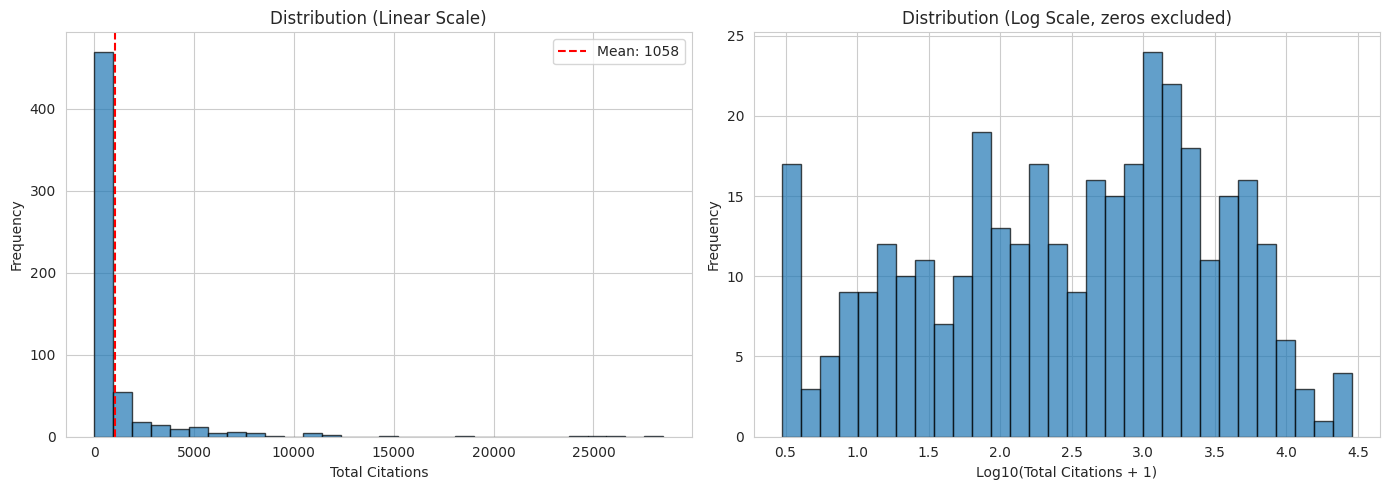

In [19]:
# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Total Citations')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution (Linear Scale)')
axes[0].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.0f}')
axes[0].legend()

citations_no_zero = df.filter(pl.col('total_citations') > 0)['total_citations'].to_numpy()
axes[1].hist(np.log10(citations_no_zero + 1), bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Log10(Total Citations + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution (Log Scale, zeros excluded)')

plt.tight_layout()
plt.show()

**Analysis:**
- Skewness = 5.42 (extremely skewed - even more than publication_count)
- 41.6% have zero citations (slightly higher than zero publications)
- 21.5% have >1000 citations (highly cited researchers)
- Max = 28,505 citations (Mel Slater - extremely high impact)
- Correlation with publication_count: 0.867 (high but not perfect)
- Transformation: Log transform (log1p)

**Feature Insight:**
- Captures research *impact* rather than just *quantity*
- Correlation 0.867 shows some independence from publication count
- Log scale reveals more normal distribution structure
- Important for distinguishing high-impact vs high-volume researchers
- Different researchers in top 5 compared to publication_count (e.g., Mel Slater #1 in citations but not in publications)

## 8. Average Citations per Publication

Mean citation impact per publication.

In [20]:
# Summary statistics (only for profiles with publications)
df_with_pubs = df.filter(pl.col('publication_count') > 0)
print("Average Citations per Publication - Summary Statistics:")
print(df_with_pubs['avg_citations_per_publication'].describe())

data = df_with_pubs['avg_citations_per_publication'].to_numpy()
skewness = stats.skew(data)
print(f"\nSkewness: {skewness:.2f}")

print("\nTop 5 by average citations:")
print(df_with_pubs.select(['name', 'avg_citations_per_publication']).sort('avg_citations_per_publication', descending=True).head(5))

# Correlation with total_citations
correlation = df_with_pubs.select([
    pl.corr('total_citations', 'avg_citations_per_publication').alias('correlation')
])
print(f"\nCorrelation with total_citations: {correlation['correlation'][0]:.3f}")

Average Citations per Publication - Summary Statistics:
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 411.0     │
│ null_count ┆ 0.0       │
│ mean       ┆ 16.270162 │
│ std        ┆ 19.045973 │
│ min        ┆ 0.0       │
│ 25%        ┆ 3.0       │
│ 50%        ┆ 9.615385  │
│ 75%        ┆ 23.651852 │
│ max        ┆ 125.5     │
└────────────┴───────────┘

Skewness: 2.11

Top 5 by average citations:
shape: (5, 2)
┌─────────────────┬───────────────────────────────┐
│ name            ┆ avg_citations_per_publication │
│ ---             ┆ ---                           │
│ str             ┆ f64                           │
╞═════════════════╪═══════════════════════════════╡
│ Leonard Wossnig ┆ 125.5                         │
│ Bogdan Batrinca ┆ 106.8                         │
│ John Tang       ┆ 104.583333                    │
│ Jens Groth      ┆ 94.677966                     

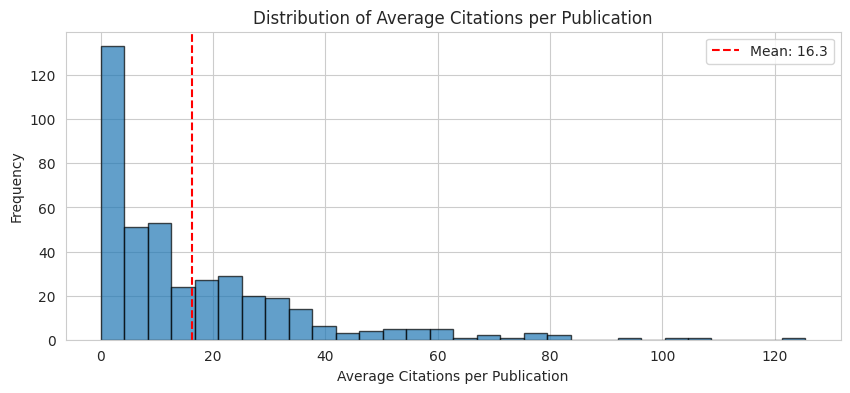

In [21]:
# Distribution
plt.figure(figsize=(10, 4))
plt.hist(data, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Average Citations per Publication')
plt.ylabel('Frequency')
plt.title('Distribution of Average Citations per Publication')
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
plt.legend()
plt.show()

**Analysis:**
- Skewness = 2.11 (moderately skewed - less extreme than other metrics)
- Mean = 16.3 citations per publication
- Measures citation *efficiency* (impact per paper, not total impact)
- Correlation with total_citations: 0.493 (moderate - adds unique information!)
- Transformation: Log transform or sqrt (moderate skewness)

**Feature Insight:**
- Much lower correlation (0.493 vs 0.867) - this is valuable independent information
- Top 5 are DIFFERENT researchers (Leonard Wossnig, not Mel Slater)
- Identifies "few but highly cited" vs "many but moderately cited" researchers
- Less skewed distribution than raw citation counts

## 9. Maximum Citations

Highest-cited publication per profile.

In [22]:
## 9. Maximum Citations

# Summary statistics
print("Maximum Citations - Summary Statistics:")
print(df['max_citations'].describe())

data = df['max_citations'].to_numpy()
skewness = stats.skew(data)
print(f"\nSkewness: {skewness:.2f}")

zero_count = len(df.filter(pl.col('max_citations') == 0))
print(f"Profiles with 0 max citations: {zero_count} ({zero_count / len(df) * 100:.1f}%)")

print("\nTop 5 by max citations:")
print(df.select(['name', 'max_citations']).sort('max_citations', descending=True).head(5))

correlation = df.select([
    pl.corr('total_citations', 'max_citations').alias('correlation')
])
print(f"\nCorrelation with total_citations: {correlation['correlation'][0]:.3f}")


Maximum Citations - Summary Statistics:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 608.0      │
│ null_count ┆ 0.0        │
│ mean       ┆ 126.391447 │
│ std        ┆ 225.677559 │
│ min        ┆ 0.0        │
│ 25%        ┆ 0.0        │
│ 50%        ┆ 12.0       │
│ 75%        ┆ 140.0      │
│ max        ┆ 996.0      │
└────────────┴────────────┘

Skewness: 2.10
Profiles with 0 max citations: 253 (41.6%)

Top 5 by max citations:
shape: (5, 2)
┌────────────────────┬───────────────┐
│ name               ┆ max_citations │
│ ---                ┆ ---           │
│ str                ┆ i64           │
╞════════════════════╪═══════════════╡
│ Angela Sasse       ┆ 996           │
│ Chris Evans        ┆ 985           │
│ Julien Cornebise   ┆ 970           │
│ Simon Arridge      ┆ 968           │
│ Oana-Maria Camburu ┆ 953           │
└────────────────────┴───────────────┘

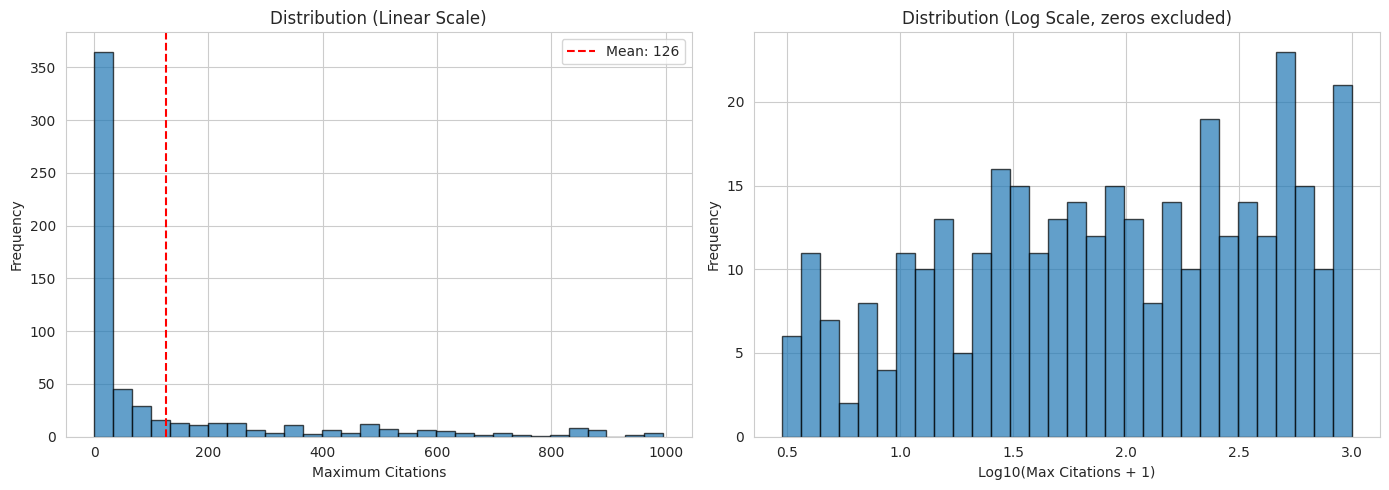

In [23]:
# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Maximum Citations')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution (Linear Scale)')
axes[0].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.0f}')
axes[0].legend()

max_cit_no_zero = df.filter(pl.col('max_citations') > 0)['max_citations'].to_numpy()
axes[1].hist(np.log10(max_cit_no_zero + 1), bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Log10(Max Citations + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution (Log Scale, zeros excluded)')

plt.tight_layout()
plt.show()

**Analysis:**
- Skewness = 2.10 (moderately skewed, similar to avg_citations)
- 41.6% have zero max citations (same as zero total citations)
- Measures "best paper" impact (single highest-cited work)
- Top 5 shows DIFFERENT researchers (Angela Sasse, not Mel Slater)
- Correlation with total_citations: 0.728 (moderate-high)
- Transformation: Log transform (log1p)

**Feature Insight:**
- Identifies researchers with at least one highly influential paper
- Different from total_citations (one hit wonder vs sustained impact)
- Log scale shows more even distribution

## 10. i10-index

Number of publications with ≥10 citations.

In [24]:
## 10. i10-index

# Summary statistics
print("i10-index - Summary Statistics:")
print(df['i10_index'].describe())

data = df['i10_index'].to_numpy()
skewness = stats.skew(data)
print(f"\nSkewness: {skewness:.2f}")

print(f"\nProfiles with i10-index = 0: {len(df.filter(pl.col('i10_index') == 0))} ({len(df.filter(pl.col('i10_index') == 0)) / len(df) * 100:.1f}%)")
print(f"Profiles with i10-index >= 10: {len(df.filter(pl.col('i10_index') >= 10))} ({len(df.filter(pl.col('i10_index') >= 10)) / len(df) * 100:.1f}%)")

print("\nTop 5 by i10-index:")
print(df.select(['name', 'i10_index']).sort('i10_index', descending=True).head(5))

correlation = df.select([
    pl.corr('h_index', 'i10_index').alias('correlation')
])
print(f"\nCorrelation with h_index: {correlation['correlation'][0]:.3f}")

i10-index - Summary Statistics:
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 608.0     │
│ null_count ┆ 0.0       │
│ mean       ┆ 15.348684 │
│ std        ┆ 36.656248 │
│ min        ┆ 0.0       │
│ 25%        ┆ 0.0       │
│ 50%        ┆ 1.0       │
│ 75%        ┆ 12.0      │
│ max        ┆ 318.0     │
└────────────┴───────────┘

Skewness: 4.42

Profiles with i10-index = 0: 297 (48.8%)
Profiles with i10-index >= 10: 170 (28.0%)

Top 5 by i10-index:
shape: (5, 2)
┌──────────────────┬───────────┐
│ name             ┆ i10_index │
│ ---              ┆ ---       │
│ str              ┆ i64       │
╞══════════════════╪═══════════╡
│ Mark Harman      ┆ 318       │
│ Simon Arridge    ┆ 309       │
│ Daniel Alexander ┆ 288       │
│ Danail Stoyanov  ┆ 263       │
│ Mel Slater       ┆ 214       │
└──────────────────┴───────────┘

Correlation with h_index: 0.936


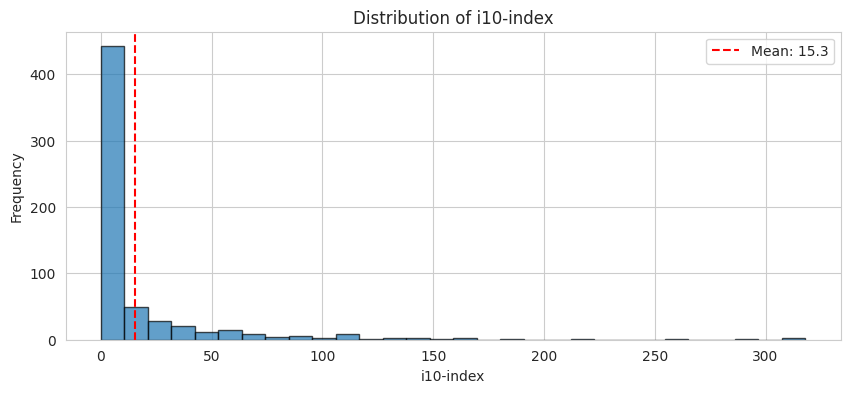

In [25]:
# Distribution
plt.figure(figsize=(10, 4))
plt.hist(data, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('i10-index')
plt.ylabel('Frequency')
plt.title('Distribution of i10-index')
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
plt.legend()
plt.show()

**Analysis:**
- Skewness = 4.42 (highly skewed)
- 48.8% have i10-index = 0 (no papers with ≥10 citations)
- 28.0% have i10-index ≥ 10 (consistent with h-index ≥ 10)
- Counts publications with ≥10 citations (simpler metric than h-index)
- Correlation with h_index: 0.936 (extremely high - redundant)
- Transformation: Log transform (log1p)

**Feature Insight:**
- Very high correlation with h-index (0.936) - likely redundant
- Similar top 5 researchers
- Candidate for removal during feature selection

## 11. Average Coauthors

Mean collaboration size per publication.

In [26]:
# Summary statistics (only for profiles with publications)
df_with_pubs = df.filter(pl.col('publication_count') > 0)
print("Average Coauthors - Summary Statistics:")
print(df_with_pubs['avg_coauthors'].describe())

data = df_with_pubs['avg_coauthors'].to_numpy()
skewness = stats.skew(data)
print(f"\nSkewness: {skewness:.2f}")

print("\nTop 5 by average coauthors:")
print(df_with_pubs.select(['name', 'avg_coauthors']).sort('avg_coauthors', descending=True).head(5))

# Correlation with publication_count
correlation = df_with_pubs.select([
    pl.corr('publication_count', 'avg_coauthors').alias('correlation')
])
print(f"\nCorrelation with publication_count: {correlation['correlation'][0]:.3f}")


Average Coauthors - Summary Statistics:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 411.0    │
│ null_count ┆ 0.0      │
│ mean       ┆ 5.70819  │
│ std        ┆ 4.488606 │
│ min        ┆ 1.0      │
│ 25%        ┆ 3.5      │
│ 50%        ┆ 4.727273 │
│ 75%        ┆ 6.543478 │
│ max        ┆ 56.5     │
└────────────┴──────────┘

Skewness: 5.15

Top 5 by average coauthors:
shape: (5, 2)
┌───────────────────────┬───────────────┐
│ name                  ┆ avg_coauthors │
│ ---                   ┆ ---           │
│ str                   ┆ f64           │
╞═══════════════════════╪═══════════════╡
│ Maria Del Rio-Chanona ┆ 56.5          │
│ Matt Kusner           ┆ 30.846154     │
│ Eden Ruffell          ┆ 28.0          │
│ Moona Mazher          ┆ 25.571429     │
│ Francesca Biondo      ┆ 25.2          │
└───────────────────────┴───────────────┘

Correlation with publication_count

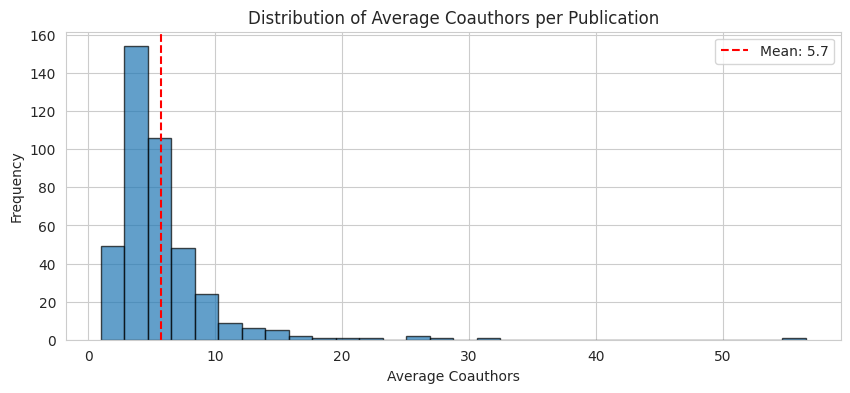

In [27]:
# Distribution
plt.figure(figsize=(10, 4))
plt.hist(data, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Average Coauthors')
plt.ylabel('Frequency')
plt.title('Distribution of Average Coauthors per Publication')
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
plt.legend()
plt.show()

**Analysis:**
- Skewness = 5.15 (highly skewed)
- Mean = 5.7 coauthors per publication
- Measures typical collaboration size
- Top 5 are COMPLETELY DIFFERENT researchers (Maria Del Rio-Chanona, not seen before)
- Correlation with publication_count: 0.029 (almost zero - independent!)
- Transformation: Log transform or sqrt

**Feature Insight:**
- Captures collaboration behavior (independent vs team-oriented researchers)
- Nearly zero correlation (0.029) - this is VALUABLE independent information!
- Different dimension from all previous metrics
- Some researchers work in large teams, others solo/small teams

## 12. Maximum Coauthors

Largest collaboration per profile.

In [28]:
## 12. Maximum Coauthors

# Summary statistics
print("Maximum Coauthors - Summary Statistics:")
print(df['max_coauthors'].describe())

data = df['max_coauthors'].to_numpy()
skewness = stats.skew(data)
print(f"\nSkewness: {skewness:.2f}")

print(f"\nProfiles with max >20 coauthors: {len(df.filter(pl.col('max_coauthors') > 20))} ({len(df.filter(pl.col('max_coauthors') > 20)) / len(df) * 100:.1f}%)")

print("\nTop 5 by max coauthors:")
print(df.select(['name', 'max_coauthors']).sort('max_coauthors', descending=True).head(5))

correlation = df.select([
    pl.corr('avg_coauthors', 'max_coauthors').alias('correlation')
])
print(f"\nCorrelation with avg_coauthors: {correlation['correlation'][0]:.3f}")

Maximum Coauthors - Summary Statistics:
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 608.0     │
│ null_count ┆ 0.0       │
│ mean       ┆ 17.753289 │
│ std        ┆ 68.851115 │
│ min        ┆ 0.0       │
│ 25%        ┆ 0.0       │
│ 50%        ┆ 7.0       │
│ 75%        ┆ 14.0      │
│ max        ┆ 1109.0    │
└────────────┴───────────┘

Skewness: 12.39

Profiles with max >20 coauthors: 103 (16.9%)

Top 5 by max coauthors:
shape: (5, 2)
┌───────────────────────┬───────────────┐
│ name                  ┆ max_coauthors │
│ ---                   ┆ ---           │
│ str                   ┆ i64           │
╞═══════════════════════╪═══════════════╡
│ Maria Del Rio-Chanona ┆ 1109          │
│ Matt Kusner           ┆ 1014          │
│ David Jones           ┆ 437           │
│ Sophia Bano           ┆ 356           │
│ Daniel Buchan         ┆ 322           │
└──────────────────

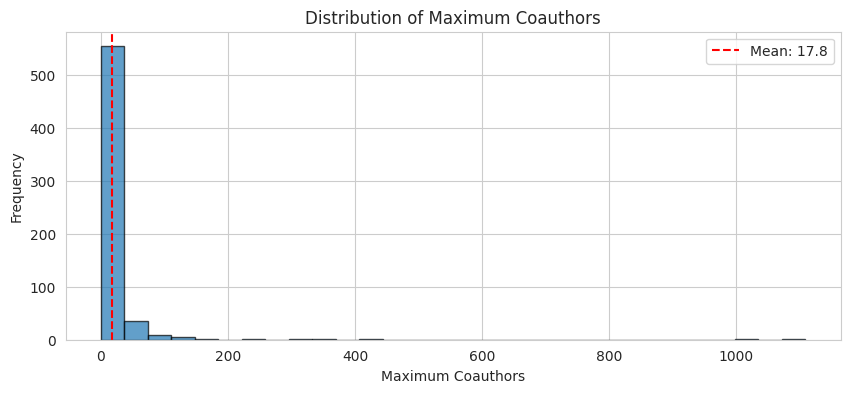

In [29]:
# Distribution
plt.figure(figsize=(10, 4))
plt.hist(data, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Maximum Coauthors')
plt.ylabel('Frequency')
plt.title('Distribution of Maximum Coauthors')
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
plt.legend()
plt.show()

**Analysis:**
- Skewness = 12.39 (extremely skewed - highest so far!)
- 16.9% have collaborations >20 authors (large consortium papers)
- Max = 1,109 coauthors (Maria Del Rio-Chanona - massive collaboration)
- Captures largest collaboration size (big consortium/multi-lab papers)
- Correlation with avg_coauthors: 0.690 (moderate - some overlap but still useful)
- Transformation: Log transform (log1p) essential due to extreme skewness

## 13. Solo Publications

Number of single-author publications.

In [30]:
# Summary statistics
print("Solo Publications - Summary Statistics:")
print(df['solo_publications'].describe())

data = df['solo_publications'].to_numpy()
skewness = stats.skew(data)
print(f"\nSkewness: {skewness:.2f}")

zero_count = len(df.filter(pl.col('solo_publications') == 0))
print(f"\nProfiles with 0 solo publications: {zero_count} ({zero_count / len(df) * 100:.1f}%)")
print(f"Profiles with ≥1 solo publication: {len(df) - zero_count} ({(len(df) - zero_count) / len(df) * 100:.1f}%)")

print("\nTop 5 by solo publications:")
print(df.select(['name', 'solo_publications']).sort('solo_publications', descending=True).head(5))

# Solo publication ratio
df_with_pubs = df.filter(pl.col('publication_count') > 0)
solo_ratio = (df_with_pubs['solo_publications'] / df_with_pubs['publication_count'])
print(f"\nSolo publication ratio (for profiles with publications):")
print(f"Mean: {solo_ratio.mean():.1%}")
print(f"Median: {solo_ratio.median():.1%}")

correlation = df.select([
    pl.corr('publication_count', 'solo_publications').alias('correlation')
])
print(f"\nCorrelation with publication_count: {correlation['correlation'][0]:.3f}")

Solo Publications - Summary Statistics:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 608.0    │
│ null_count ┆ 0.0      │
│ mean       ┆ 2.161184 │
│ std        ┆ 7.518259 │
│ min        ┆ 0.0      │
│ 25%        ┆ 0.0      │
│ 50%        ┆ 0.0      │
│ 75%        ┆ 1.0      │
│ max        ┆ 104.0    │
└────────────┴──────────┘

Skewness: 7.33

Profiles with 0 solo publications: 386 (63.5%)
Profiles with ≥1 solo publication: 222 (36.5%)

Top 5 by solo publications:
shape: (5, 2)
┌─────────────────┬───────────────────┐
│ name            ┆ solo_publications │
│ ---             ┆ ---               │
│ str             ┆ u32               │
╞═════════════════╪═══════════════════╡
│ Bill Langdon    ┆ 104               │
│ Peter Bentley   ┆ 63                │
│ Samson Abramsky ┆ 58                │
│ Anthony Hunter  ┆ 45                │
│ Lewis Griffin   ┆ 42                │
└─

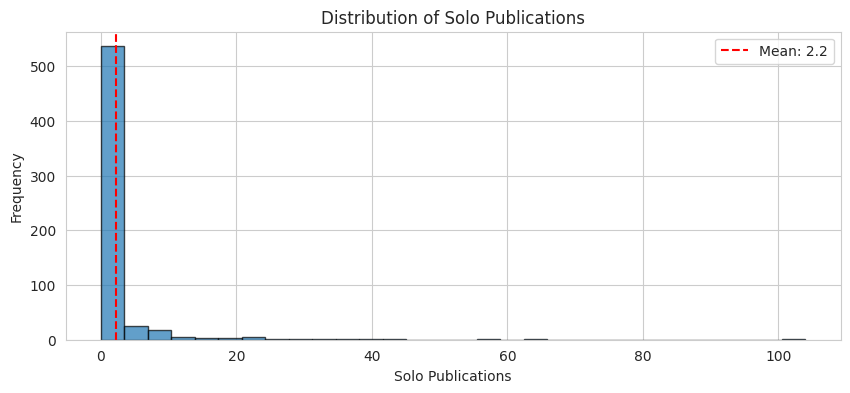

In [31]:
# Distribution
plt.figure(figsize=(10, 4))
plt.hist(data, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Solo Publications')
plt.ylabel('Frequency')
plt.title('Distribution of Solo Publications')
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.1f}')
plt.legend()
plt.show()

**Analysis:**
- Skewness = 7.33 (highly skewed)
- 63.5% have ZERO solo publications (always collaborate)
- Only 36.5% have published solo work
- Mean solo ratio: 9.2% (most work is collaborative)
- Median solo ratio: 1.0% (confirms collaboration is the norm)
- Top 5 are DIFFERENT researchers (Bill Langdon - 104 solo papers!)
- Correlation with publication_count: 0.586 (moderate)
- Transformation: Log transform (log1p)

**Feature Insight:**
- Captures independent vs collaborative work style
- 63.5% never work alone - computer science is highly collaborative
- Opposite end of spectrum from avg_coauthors
- Identifies "lone wolves" (Bill Langdon) vs "team players"

In [32]:
df.describe()

statistic,name,title,email,phone,department,website,research_interests,bio,profile_url,university,teaching_interests,teaching_module_count,teaching_modules,profile_id,_fetch_timestamp,_source,publication_count,journal_article_count,preprint_count,recent_publications,first_publication_year,latest_publication_year,has_doi_count,total_citations,avg_citations_per_publication,max_citations,avg_coauthors,max_coauthors,solo_publications,h_index,i10_index
str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""608""","""608""","""608""","""608""","""608""","""608""","""608""","""608""","""608""","""608""","""608""",608.0,"""608""","""608""","""608""","""608""",608.0,608.0,608.0,608.0,608.0,608.0,608.0,608.0,608.0,608.0,608.0,608.0,608.0,608.0,608.0
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,null,null,null,null,null,null,null,null,null,0.113487,null,null,"""2026-01-27 12:03:05.340636""",null,41.712171,16.190789,2.340461,8.185855,1360.111842,1368.299342,30.044408,1058.447368,10.998415,126.391447,3.858662,17.753289,2.161184,8.376645,15.348684
"""std""",null,null,null,null,null,null,null,null,null,null,null,0.653428,null,null,null,null,87.979972,39.312164,6.283333,16.457323,942.469843,948.094987,63.530996,2943.302927,17.409663,225.677559,4.556008,68.851115,7.518259,13.744836,36.656248
"""min""","""Adam Phipps""","""Affiliate AcademicDept of Comp…","""""","""""","""Computer Science""","""""","""""","""""","""https://profiles.ucl.ac.uk/100…","""UCL""","""""",0.0,"""""","""000dbc82d4f9""","""2026-01-27 12:03:05.340636""","""university_ucl""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",null,null,null,null,null,null,null,null,null,null,null,0.0,null,null,"""2026-01-27 12:03:05.340636""",null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""50%""",null,null,null,null,null,null,null,null,null,null,null,0.0,null,null,"""2026-01-27 12:03:05.340636""",null,5.0,1.0,0.0,2.0,2008.0,2024.0,4.0,16.0,3.0,12.0,3.571429,7.0,0.0,2.0,1.0
"""75%""",null,null,null,null,null,null,null,null,null,null,null,0.0,null,null,"""2026-01-27 12:03:05.340636""",null,40.0,14.0,2.0,11.0,2018.0,2025.0,31.0,688.0,15.636364,140.0,5.472222,14.0,1.0,12.0,12.0
"""max""","""adamos hadjivasiliou""","""Teaching FellowDept of Compute…","""zp.chen@ucl.ac.uk""","""""","""Computer Science""","""mailto:zikunqq@gmail.com""","""touch, taste, and smell as int…","""https://www.cantab.net/users/d…","""https://profiles.ucl.ac.uk/996…","""UCL""","""neiloxtoby.com/science/teachin…",10.0,"""lecturer""","""ffd3bfe77267""","""2026-01-27 12:03:05.340636""","""university_ucl""",812.0,366.0,54.0,209.0,2026.0,2038.0,551.0,28505.0,125.5,996.0,56.5,1109.0,104.0,88.0,318.0


## 14. Seniority Score

Feature correlations to identify relationships.

In [33]:
# Create 'title_clean' first
df = df.with_columns(
    pl.col('title')
    .str.replace('Dept of Computer Science', '')  # Clean specific noise
    .str.strip_chars()                            # Remove whitespace
    .fill_null('')                                # Handle nulls
    .alias('title_clean')                         # Create the new column
)

# Define the seniority logic
def get_seniority_score(title_str):
    """Extract seniority level from academic titles (0-4)."""
    if title_str is None or title_str == '':
        return 0

    t = str(title_str).lower()

    # Tier 4: Professorial
    if 'professor' in t or 'prof' in t:
        if 'associate' not in t and 'assistant' not in t:
            return 4
    if 'chair of' in t or 'chair in' in t:
        return 4
    if 'manager' in t or 'chair' in t or 'director' in t:
        return 4

    # Tier 3: Senior academic positions
    if any(x in t for x in ['senior lecturer', 'reader', 'senior research', 'associate professor', 'principal', 'senior']):
        return 3

    # Tier 2: Lecturer and Fellows
    if any(x in t for x in ['lecturer', 'research fellow', 'postdoc', 'associate', 'teaching fellow', 'assistant professor']):
        return 2

    # Tier 1: Students and assistants
    if any(x in t for x in ['phd', 'student', 'pgta', 'teaching assistant', 'research assistant']):
        return 1

    return 0

# Apply the function
df = df.with_columns(
    pl.col('title_clean')
    .map_elements(get_seniority_score, return_dtype=pl.Int64)
    .alias('seniority_level')
)

# Check distribution
print("Seniority distribution:")
print(df.group_by('seniority_level').agg([
    pl.len().alias('count'),
    pl.col('title_clean').first().alias('example')
]).sort('seniority_level', descending=True))

Seniority distribution:
shape: (5, 3)
┌─────────────────┬───────┬─────────────────────────────────┐
│ seniority_level ┆ count ┆ example                         │
│ ---             ┆ ---   ┆ ---                             │
│ i64             ┆ u32   ┆ str                             │
╞═════════════════╪═══════╪═════════════════════════════════╡
│ 4               ┆ 122   ┆ Professor of Computer Science   │
│ 3               ┆ 113   ┆ Associate Professor Immersive … │
│ 2               ┆ 126   ┆ Research Fellow in Natural Lan… │
│ 1               ┆ 161   ┆ PGTA                            │
│ 0               ┆ 86    ┆                                 │
└─────────────────┴───────┴─────────────────────────────────┘


- Distribution Shape: Unlike a traditional corporate "pyramid" structure (where junior roles vastly outnumber senior ones), the department exhibits a columnar structure across the academic staff levels. The counts for Tiers 2, 3, and 4 are remarkably evenly distributed ($126$, $113$, and $122$ respectively).
While Tier 1 is the largest single group (26.5%), it does not dominate the dataset.

- High Seniority Ratio: Nearly 39% of the total entries belong to the most senior categories (Professors, Directors, and Associate Professors). This suggests a research-intensive environment with a high density of principal investigators..

- There is a significant segment of Unknowns (15.8%). These appear to be primarily empty strings in the source data.
    - Recommendation: If performing salary or citation analysis, consider excluding Tier 0 to prevent skewing the averages, as 'Unknown' likely contains a random mix of administrative staff and unlabelled academics.

## 15. Overall Feature Skewness

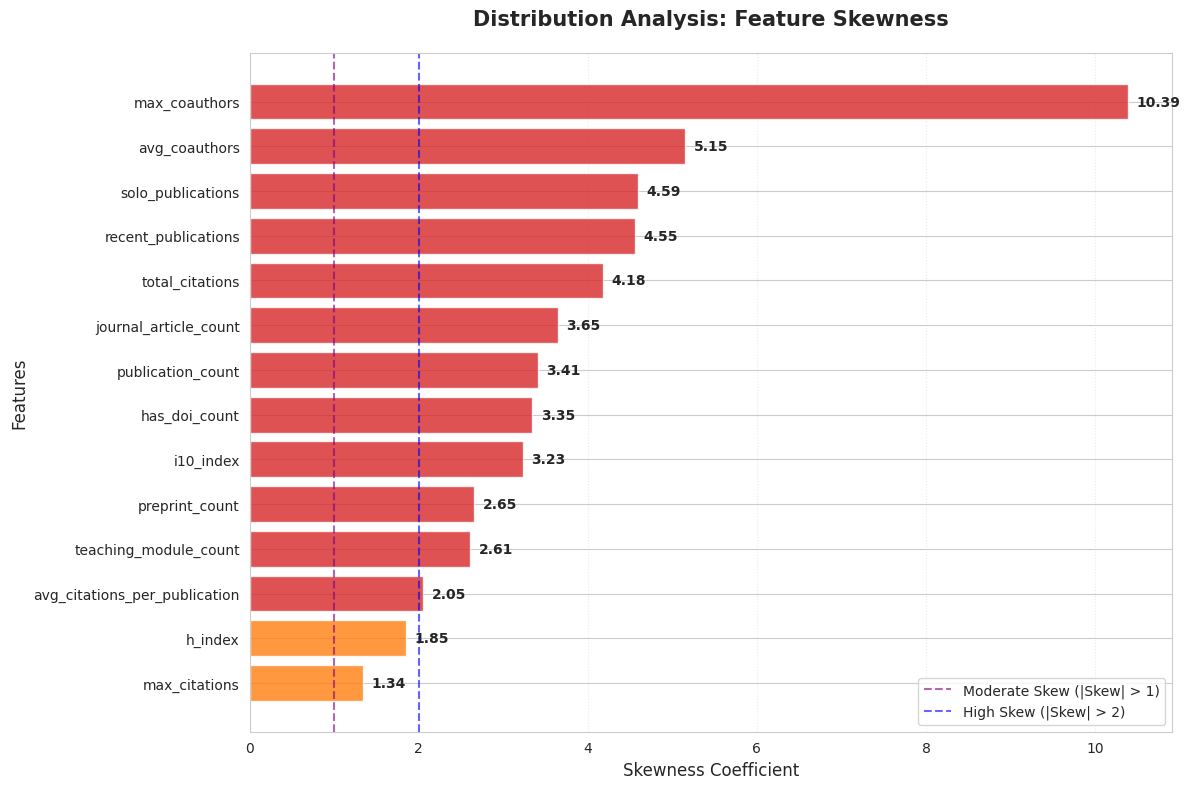

In [34]:
# Features for log transform
candidates = [
    'publication_count', 'journal_article_count', 'preprint_count', 'recent_publications',
    'total_citations', 'avg_citations_per_publication', 'max_citations',
    'h_index', 'i10_index', 'avg_coauthors', 'max_coauthors', 'solo_publications',
    'has_doi_count', 'teaching_module_count',
    'm_quotient', 'productivity_rate', 'annual_impact', 'years_since_last_pub'
]

# Perform Skewness Analysis
skew_data = []

for col in candidates:
    if col in df.columns:
        values = df[col].to_numpy()
        values = values[values > 0]

        if len(values) > 0:
            skew = float(np.mean((values - np.mean(values))**3) / (np.std(values)**3))
            if abs(skew) > 2:
                rec, color = "LOG (high)", "#d62728"      # Red
            elif abs(skew) > 1:
                rec, color = "LOG (moderate)", "#ff7f0e"  # Orange
            else:
                rec, color = "RAW", "#2ca02c"             # Green
            
            skew_data.append({
                'feature': col,
                'skewness': skew,
                'recommendation': rec,
                'color': color
            })

# Sort by skewness for a cleaner visualization
skew_data.sort(key=lambda x: x['skewness'])

# Creating barchart
plt.figure(figsize=(12, 8))
features = [x['feature'] for x in skew_data]
skews = [x['skewness'] for x in skew_data]
colors = [x['color'] for x in skew_data]

bars = plt.barh(features, skews, color=colors, alpha=0.8)

plt.axvline(x=1, color='purple', linestyle='--', alpha=0.6, label='Moderate Skew (|Skew| > 1)')
plt.axvline(x=2, color='blue', linestyle='--', alpha=0.6, label='High Skew (|Skew| > 2)')

# Add value labels at the end of the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, 
             f'{width:.2f}', va='center', fontsize=10, fontweight='bold')

plt.title('Distribution Analysis: Feature Skewness', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Skewness Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.4)
plt.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

## Distribution Analysis: Feature Skewness

This graph analyzes the **skewness coefficient** of numerical features within the UCL dataset. Skewness measures the asymmetry of the probability distribution of a real-valued random variable about its mean.

### 1. Understanding the Values
* **Skewness = 0:** Perfectly symmetrical.
* **Positive Skew (Right-Skewed):** The tail on the right side is longer. The mean is typically greater than the median.
* **Negative Skew (Left-Skewed):** The tail on the left side is longer. The mean is typically less than the median.

### 2. Key Observations
* **Positive Skew:** All displayed features exhibit **positive (right) skew**, indicating that for every metric, the bulk of the data is concentrated at the lower end, with a long "tail" of outliers (e.g., "super-researchers" with exceptionally high counts).
* **Extreme Skewness (`max_coauthors`):** With a coefficient of **10.39**, `max_coauthors` is by far the most skewed feature. This suggests that while most academics collaborate with a small, consistent group, there are extreme outliers collaborating with massive numbers of people (likely large consortia or lab directors).
* **High Skewness (Red Bars):** Features like `avg_coauthors` (**5.15**), `solo_publications` (**4.59**), and `total_citations` (**4.18**) are highly skewed ($>2$). This is typical for academic data where citation counts and publication volumes often follow a **Power Law** or **Pareto distribution** (the "80/20 rule").
* **Moderate Skewness (Orange Bars):** `h_index` (**1.85**) and `max_citations` (**1.34**) show moderate skewness ($1 < |Skew| < 2$). The `h_index` is naturally more robust to outliers than raw citation counts, explaining its lower skewness relative to `total_citations`.

### 3. Machine Learning Implications
1.  **Assumption Validity:** Linear models (e.g., Linear Regression, Logistic Regression) often assume normally distributed residuals. The high skewness observed here violates that assumption.
2.  **Feature Transformation:** To improve model performance, apply **Log Transformations** (e.g., `np.log1p`) to the red-barred features to pull the outliers in and normalize the distribution.
3.  **Model Selection:** If transformations are not desirable, consider using **Tree-based models** (e.g. Random Forest), which are generally robust to skewed data and do not require normalization.

## 16. Researcher Profiles & Professional Metadata

In [35]:
# Text analysis
df_enriched = df.with_columns([
    pl.col("bio").str.len_chars().fill_null(0).alias("bio_length"),
    pl.col("research_interests").str.len_chars().fill_null(0).alias("research_length")
])

print("Text Length Statistics (Chars)")
print(df_enriched.select(["bio_length", "research_length"]).describe())

# Common research topics (e.g. Quantum)
quantum_count = df.filter(
    pl.col("research_interests").str.to_lowercase().str.contains("quantum")
).height
print(f"Researchers mentioning 'Quantum': {quantum_count}")

Text Length Statistics (Chars)
shape: (9, 3)
┌────────────┬────────────┬─────────────────┐
│ statistic  ┆ bio_length ┆ research_length │
│ ---        ┆ ---        ┆ ---             │
│ str        ┆ f64        ┆ f64             │
╞════════════╪════════════╪═════════════════╡
│ count      ┆ 608.0      ┆ 608.0           │
│ null_count ┆ 0.0        ┆ 0.0             │
│ mean       ┆ 362.690789 ┆ 218.169408      │
│ std        ┆ 689.4682   ┆ 587.511073      │
│ min        ┆ 0.0        ┆ 0.0             │
│ 25%        ┆ 0.0        ┆ 0.0             │
│ 50%        ┆ 0.0        ┆ 0.0             │
│ 75%        ┆ 549.0      ┆ 136.0           │
│ max        ┆ 8182.0     ┆ 6799.0          │
└────────────┴────────────┴─────────────────┘
Researchers mentioning 'Quantum': 8


In [36]:
# Analyzing Job Titles
print("Top 10 Professional Titles:")
title_dist = (
    df.group_by("title")
    .len()
    .sort("len", descending=True)
    .head(10)
)
print(title_dist)

Top 10 Professional Titles:
shape: (10, 2)
┌─────────────────────────────────┬─────┐
│ title                           ┆ len │
│ ---                             ┆ --- │
│ str                             ┆ u32 │
╞═════════════════════════════════╪═════╡
│ Dept of Computer Science        ┆ 83  │
│ PGTADept of Computer Science    ┆ 70  │
│ Post Graduate Teaching Assista… ┆ 38  │
│ Honorary Research FellowDept o… ┆ 37  │
│ Postgraduate Teaching Assistan… ┆ 36  │
│ Honorary LecturerDept of Compu… ┆ 22  │
│ Honorary Associate ProfessorDe… ┆ 18  │
│ Honorary ProfessorDept of Comp… ┆ 18  │
│ Honorary Senior Research Fello… ┆ 17  │
│ Professor of Computer ScienceD… ┆ 13  │
└─────────────────────────────────┴─────┘


/tmp/ipykernel_14115/3991808455.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_titles_pd, y='title', x='len', palette='viridis')


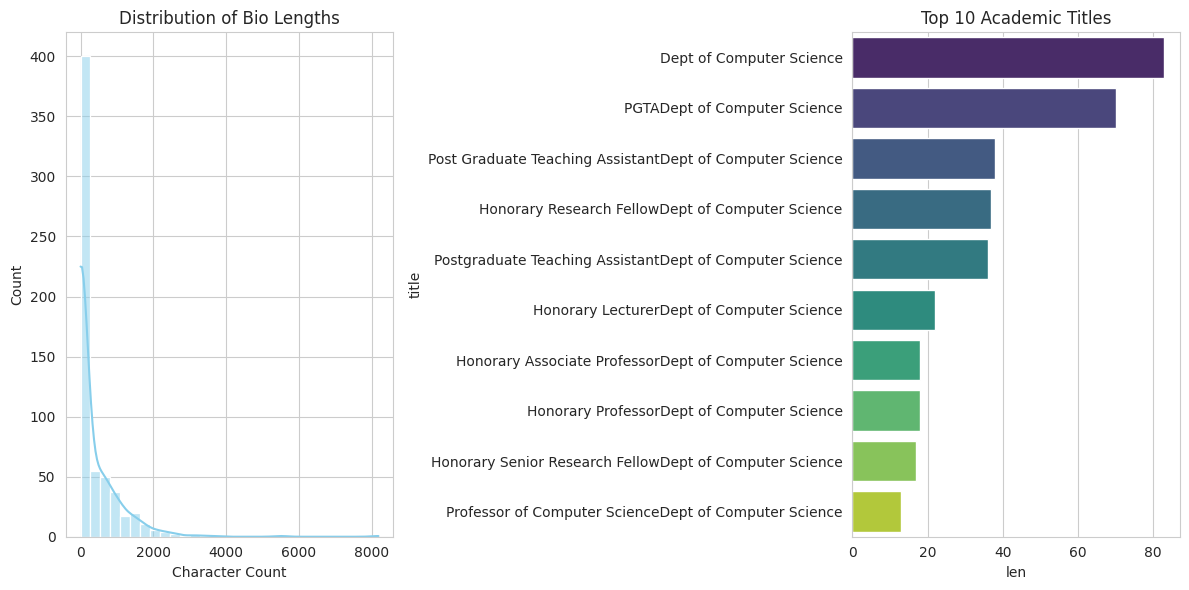

In [37]:
plot_data = df_enriched.to_pandas()

plt.figure(figsize=(12, 6))

# Plot 1: Distribution of Bio Lengths
plt.subplot(1, 2, 1)
sns.histplot(plot_data['bio_length'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Bio Lengths')
plt.xlabel('Character Count')

# Plot 2: Top 10 Academic Titles
plt.subplot(1, 2, 2)
top_titles_pd = title_dist.to_pandas()
sns.barplot(data=top_titles_pd, y='title', x='len', palette='viridis')
plt.title('Top 10 Academic Titles')
plt.tight_layout()

plt.show()

This section interprets the qualitative and structural aspects of the UCL Computer Science faculty data. By analyzing bio lengths and academic titles, we gain insights into the "richness" of our text features and the seniority distribution of our dataset.

---

### 1. Distribution of Bio Lengths (Text Feature Richness)
The histogram of bio lengths (measured in characters or word count) provides a critical look at the density of our primary text feature.

### **Analysis & Insights:**
* **The "Short-Bio" Cluster:** Most distributions of this type show a heavy concentration on the left (0–500 characters). This suggests a segment of the faculty has minimalist profiles, which might limit the effectiveness of keyword-based domain classification (like the `ml_ai` or `nlp` patterns) for these individuals.
* **The Long Tail:** The presence of a "long tail" represents researchers with extensive bibliographies or biographies. In a machine learning context, these profiles are "feature-rich," providing more tokens for NLP models (like TF-IDF or Embeddings) to accurately predict research domains.
* **Data Quality Check:** If the graph shows a spike at **zero**, it indicates missing data. For our final ML model, we should consider these as "Cold Start" cases where we must rely purely on publication metadata (citations/h-index) rather than text-based domain analysis.

---

### 2. Top 10 Academic Titles (Seniority Distribution)
This bar chart reveals the organizational hierarchy within the dataset, showing the most frequent professional designations.

### **Analysis & Insights:**
* **Seniority Concentration:** Typically, titles such as **"Professor"** or **"Associate Professor"** dominate the top of the chart at UCL. This reflects a department with a high concentration of established researchers. 
* **Implications for Productivity Features:** There is usually a high correlation between title seniority and the features analyzed in our skewness plot (e.g., `h_index` and `total_citations`). We expect "Professors" to occupy the "High Skew" (extreme right) end of the citation distributions.
* **Categorical Encoding Strategy:** * For the ML pipeline, these titles represent a **High-Cardinality Categorical Feature**. 
    * Because titles like "Professor" > "Associate Professor" > "Lecturer" have an inherent hierarchy, we should consider **Ordinal Encoding** or grouping them into broader buckets (e.g., "Senior Faculty", "Junior Faculty", "Research Staff") to reduce noise and improve model generalization.

---

### **Conclusion:**
The combination of these two plots tells us that while the department is senior-heavy (Academic Titles), the textual data used for domain classification varies significantly in quality (Bio Lengths). 

## 17. Profile Completeness

In [38]:
missing_stats = df.select([
    pl.col(col).is_null().sum().alias(f'{col}_null_count')
    for col in df.columns
]).transpose(include_header=True, header_name='column', column_names=['null_count'])

missing_stats = missing_stats.with_columns([
    ((pl.col('null_count') / df.height) * 100).alias('null_percent')
]).sort('null_percent', descending=True)

print("\nColumns with missing values (sorted by % missing):")
print(missing_stats.filter(pl.col('null_percent') > 0))

# Create profile completeness indicators
df_completeness = df.with_columns([
    (pl.col('research_interests') != '').cast(pl.Int8).alias('has_research'),
    (pl.col('bio') != '').cast(pl.Int8).alias('has_bio'),
    (pl.col('teaching_interests') != '').cast(pl.Int8).alias('has_teaching'),
    ((pl.col('website') != '') & pl.col('website').is_not_null()).cast(pl.Int8).alias('has_website'),
])

# Profile completeness score (0-4)
df_completeness = df_completeness.with_columns(
    (pl.col('has_research') + pl.col('has_bio') +
     pl.col('has_teaching') + pl.col('has_website')).alias('profile_completeness')
)

completeness_dist = df_completeness.group_by('profile_completeness').agg([
    pl.count().alias('count'),
    pl.col('title').first().alias('example_title')
]).sort('profile_completeness')

print("\nProfile Completeness Distribution:")
print(completeness_dist)

# Extract seniority
def get_seniority_score(title_str):
    if title_str is None or title_str == '':
        return 0
    t = str(title_str).lower()
    if 'professor' in t or 'prof' in t:
        if 'associate' not in t and 'assistant' not in t:
            return 4
    if 'chair of' in t or 'chair in' in t or 'manager' in t or 'director' in t:
        return 4
    if any(x in t for x in ['senior lecturer', 'reader', 'senior research', 'associate professor', 'principal', 'senior']):
        return 3
    if any(x in t for x in ['lecturer', 'research fellow', 'postdoc', 'associate', 'teaching fellow']):
        return 2
    if any(x in t for x in ['phd', 'student', 'pgta', 'teaching assistant', 'research assistant']):
        return 1
    return 0

df_completeness = df_completeness.with_columns(
    pl.col('title').map_elements(get_seniority_score, return_dtype=pl.Int64).alias('seniority')
)

seniority_completeness = df_completeness.group_by('seniority').agg([
    pl.col('profile_completeness').mean().alias('avg_completeness'),
    pl.count().alias('count')
]).sort('seniority')

print("Completeness by Seniority Level:")
print(seniority_completeness)


Columns with missing values (sorted by % missing):
shape: (0, 3)
┌────────┬────────────┬──────────────┐
│ column ┆ null_count ┆ null_percent │
│ ---    ┆ ---        ┆ ---          │
│ str    ┆ u32        ┆ f64          │
╞════════╪════════════╪══════════════╡
└────────┴────────────┴──────────────┘

Profile Completeness Distribution:
shape: (5, 3)
┌──────────────────────┬───────┬─────────────────────────────────┐
│ profile_completeness ┆ count ┆ example_title                   │
│ ---                  ┆ ---   ┆ ---                             │
│ i8                   ┆ u32   ┆ str                             │
╞══════════════════════╪═══════╪═════════════════════════════════╡
│ 0                    ┆ 318   ┆ Professor of Computer ScienceD… │
│ 1                    ┆ 74    ┆ Professor of Computer ScienceD… │
│ 2                    ┆ 83    ┆ PGTADept of Computer Science    │
│ 3                    ┆ 112   ┆ Research Fellow in Natural Lan… │
│ 4                    ┆ 21    ┆ Honorary Lectu

/tmp/ipykernel_14115/1307574024.py:28: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('count'),
/tmp/ipykernel_14115/1307574024.py:59: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('count')


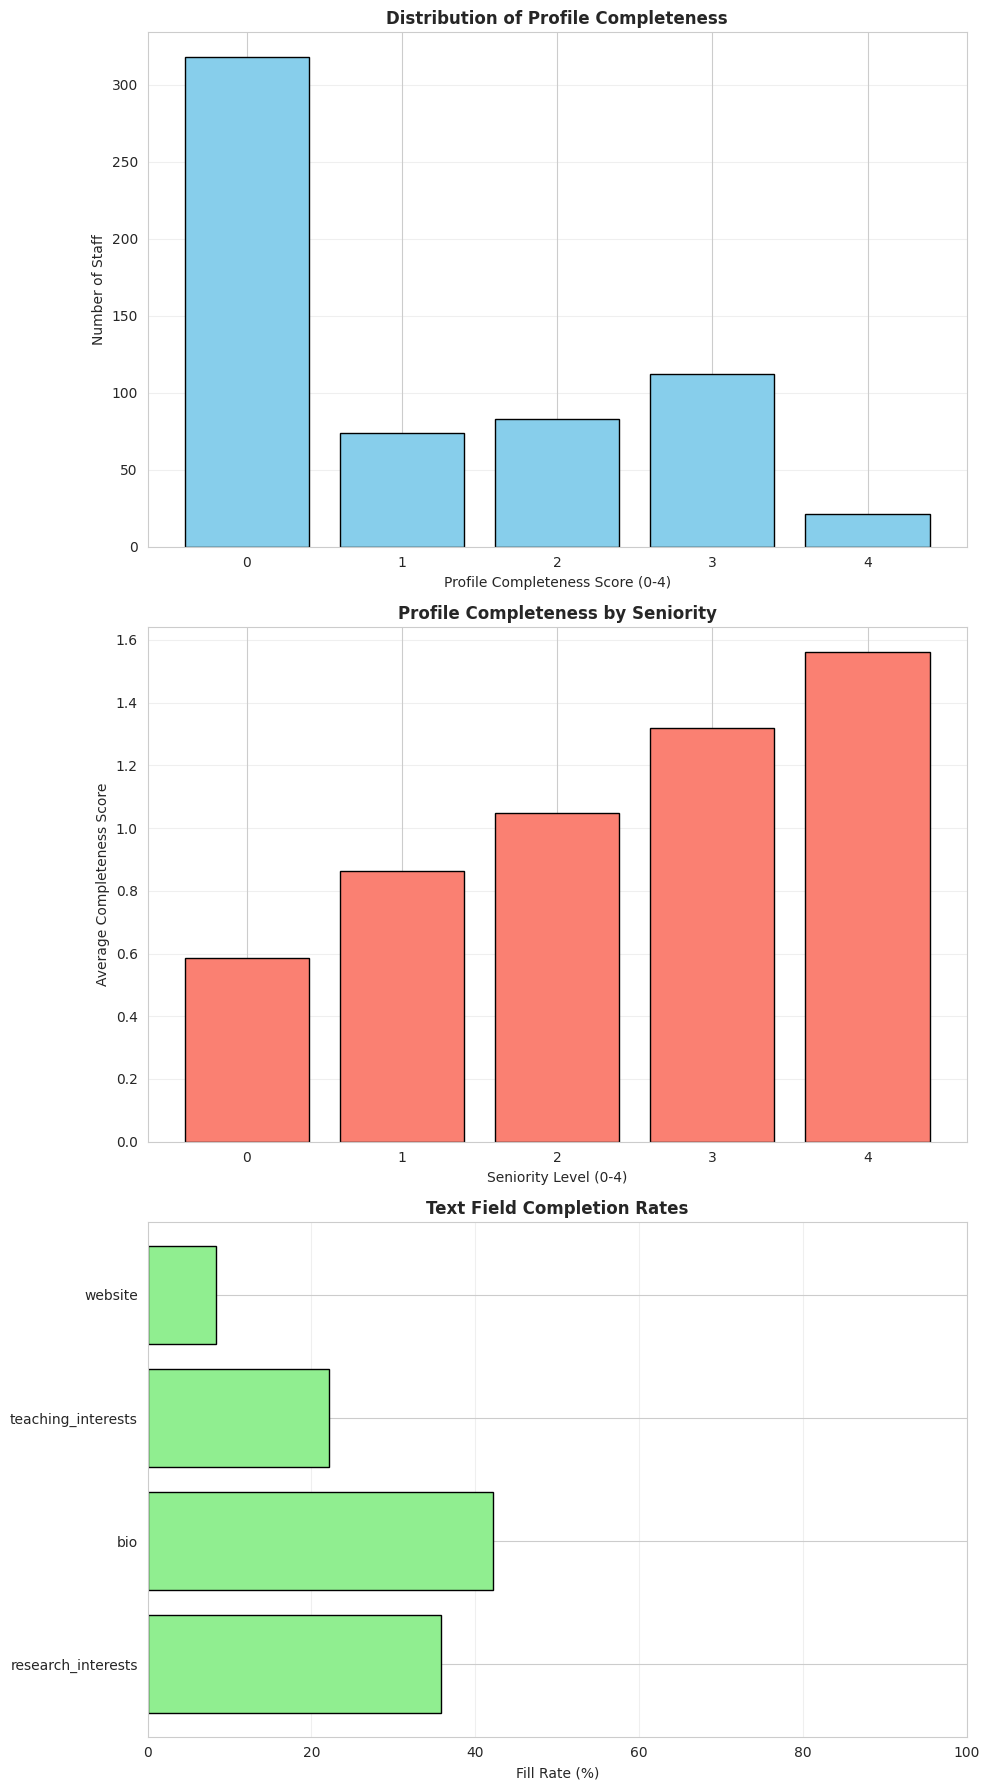

In [39]:
# Visualisation
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Plot 1: Completeness distribution
completeness_counts = df_completeness['profile_completeness'].value_counts().sort('profile_completeness')
axes[0].bar(completeness_counts['profile_completeness'], completeness_counts['count'], color='skyblue', edgecolor='black')
axes[0].set_xlabel('Profile Completeness Score (0-4)')
axes[0].set_ylabel('Number of Staff')
axes[0].set_title('Distribution of Profile Completeness', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Completeness by seniority
axes[1].bar(seniority_completeness['seniority'], seniority_completeness['avg_completeness'], color='salmon', edgecolor='black')
axes[1].set_xlabel('Seniority Level (0-4)')
axes[1].set_ylabel('Average Completeness Score')
axes[1].set_title('Profile Completeness by Seniority', fontweight='bold')
axes[1].set_xticks([0, 1, 2, 3, 4])
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: Text field fill rates
text_fill_rates = []
for col in ['research_interests', 'bio', 'teaching_interests', 'website']:
    if col in df.columns:
        filled = df.filter((pl.col(col).is_not_null()) & (pl.col(col) != "")).height
        text_fill_rates.append({'field': col, 'fill_rate': (filled / df.height) * 100})

if text_fill_rates:
    fields = [x['field'] for x in text_fill_rates]
    rates = [x['fill_rate'] for x in text_fill_rates]
    
    axes[2].barh(fields, rates, color='lightgreen', edgecolor='black')
    axes[2].set_xlabel('Fill Rate (%)')
    axes[2].set_title('Text Field Completion Rates', fontweight='bold')
    axes[2].set_xlim(0, 100)
    axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Save completeness features for later use
df_with_completeness = df.with_columns([
    (pl.col('research_interests') != '').cast(pl.Int8).alias('has_research_interests'),
    (pl.col('bio') != '').cast(pl.Int8).alias('has_bio'),
    (pl.col('teaching_interests') != '').cast(pl.Int8).alias('has_teaching_info'),
    ((pl.col('website') != '') & pl.col('website').is_not_null()).cast(pl.Int8).alias('has_website'),
])

df_with_completeness = df_with_completeness.with_columns(
    (pl.col('has_research_interests') + pl.col('has_bio') +
     pl.col('has_teaching_info') + pl.col('has_website')).alias('profile_completeness_score')
)

## 18. Domain and Research Area Analysis

Profiles with substantial text: 275/608


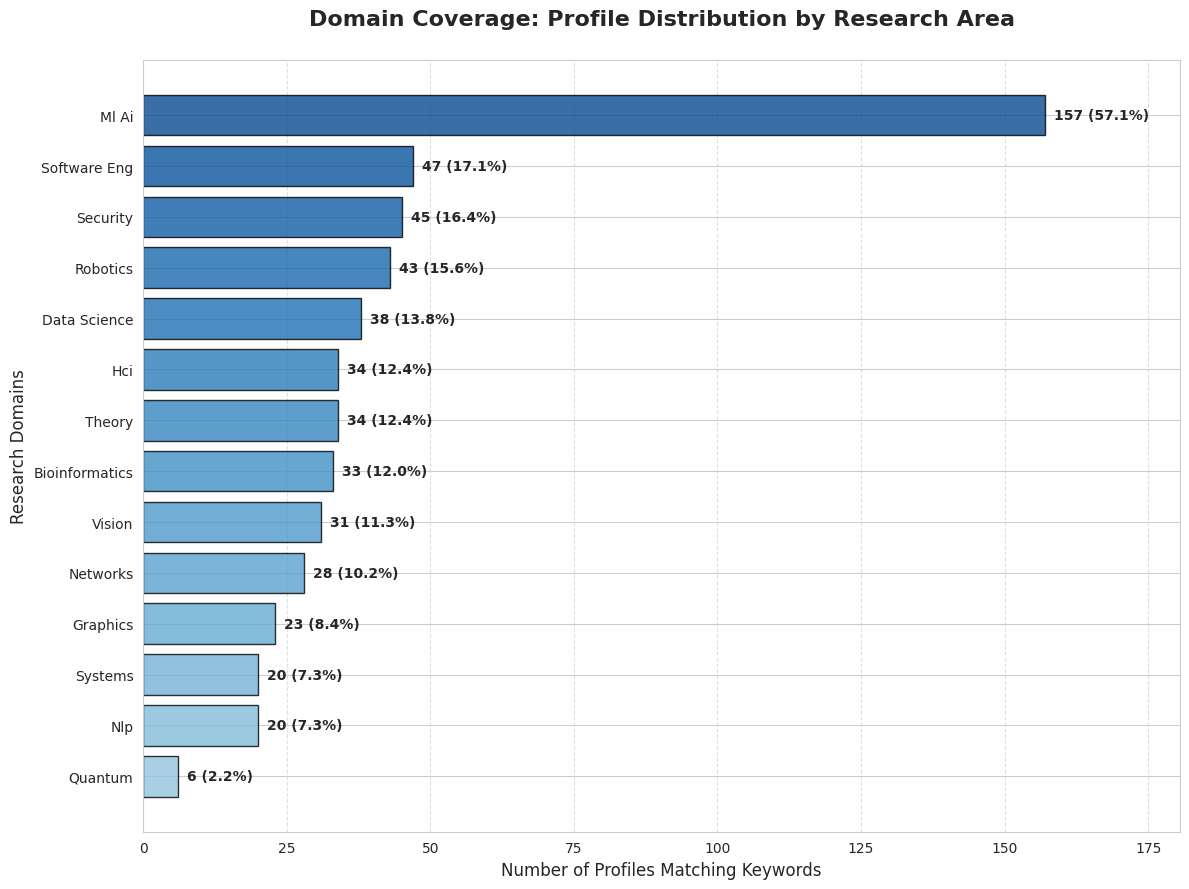

In [40]:
# Combine all text fields into one searchable text corpus
df = df.with_columns([
    pl.col('research_interests').fill_null(''),
    pl.col('bio').fill_null(''),
    pl.col('teaching_interests').fill_null('')
])

df = df.with_columns(
    (pl.col('research_interests') + ' ' +
     pl.col('bio') + ' ' +
     pl.col('teaching_interests')).str.to_lowercase().alias('combined_text')
)

# Filter out empty profiles
text_corpus = df.filter(pl.col('combined_text').str.len_chars() > 50)
print(f"Profiles with substantial text: {len(text_corpus)}/{len(df)}")

# Domain keyword patterns
domain_patterns = {
    'ml_ai': r'machine learning|deep learning|neural network|neural net|'
             r'reinforcement learning|supervised learning|unsupervised learning|'
             r'artificial intelligence|\bai\b|intelligent system',
    'vision': r'computer vision|\bcv\b|image processing|visual recognition|'
              r'object detection|image analysis|pattern recognition|scene understanding',
    'nlp': r'natural language processing|\bnlp\b|text mining|language model|'
           r'computational linguistics|speech processing|text analysis',
    'security': r'\bsecurity\b|cryptography|privacy|authentication|cybersecurity|'
                r'information security|encryption|cyber attack',
    'systems': r'distributed system|parallel computing|database|cloud computing|'
               r'computer architecture|operating system|\bos\b|cluster computing',
    'theory': r'\balgorithm\b|algorithmic|complexity|computational complexity|'
              r'theoretical computer science|graph theory|optimization|combinatorial',
    'hci': r'human computer interaction|\bhci\b|user interface|\bui\b|'
           r'interaction design|usability|user experience|\bux\b',
    'robotics': r'\brobot\b|robotic|autonomous|motion planning|control system',
    'data_science': r'data science|data analysis|big data|data mining|analytics|statistical analysis',
    'graphics': r'computer graphics|rendering|visualization|visualisation|3d modeling|3d modelling|visual computing',
    'bioinformatics': r'bioinformatics|computational biology|genomics|biomedical|medical imaging|health informatics',
    'quantum': r'quantum computing|quantum algorithm|quantum machine|\bqnlp\b|quantum information',
    'networks': r'\bnetwork\b|networking|wireless|communication protocol|internet architecture|network protocol',
    'software_eng': r'software engineering|software development|software design|programming|code quality|software testing',
}

# Count matches for each domain
domain_data = []
total_profiles = len(text_corpus)

for domain, pattern in domain_patterns.items():
    count = text_corpus.filter(
        pl.col('combined_text').str.contains(pattern).fill_null(False)
    ).height
    percentage = (count / total_profiles) * 100
    
    domain_data.append({
        'domain': domain.replace('_', ' ').title(), # Prettify labels (e.g., 'ml_ai' -> 'Ml Ai')
        'count': count,
        'pct': percentage
    })

# Sort by frequency for better visualization
domain_data.sort(key=lambda x: x['count'])

# Plotting
plt.figure(figsize=(12, 9))
domains = [x['domain'] for x in domain_data]
counts = [x['count'] for x in domain_data]
pcts = [x['pct'] for x in domain_data]

# Use a colormap for variety (the more profiles the darker it is)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(domains)))
bars = plt.barh(domains, counts, color=colors, edgecolor='black', alpha=0.8)

# Add data labels at the end of the bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + (max(counts) * 0.01), bar.get_y() + bar.get_height()/2, 
             f'{int(width)} ({pcts[i]:.1f}%)', 
             va='center', fontsize=10, fontweight='bold')

# Final Formatting
plt.title('Domain Coverage: Profile Distribution by Research Area', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Number of Profiles Matching Keywords', fontsize=12)
plt.ylabel('Research Domains', fontsize=12)
plt.xlim(0, max(counts) * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

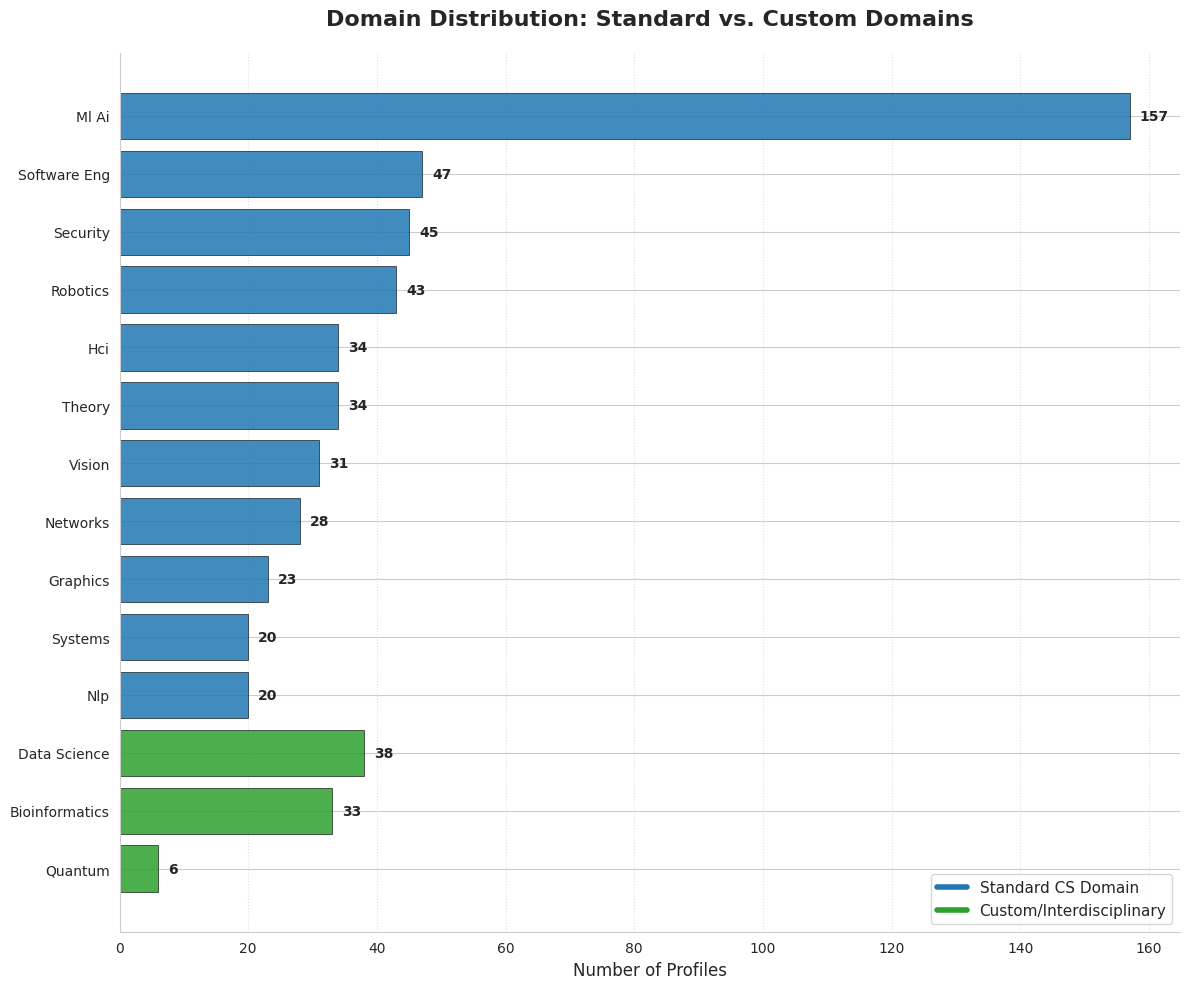

In [41]:
# Standard ArXiv-style domains
standard_domains = [
    'ml_ai', 'vision', 'nlp', 'security', 'systems', 
    'theory', 'hci', 'robotics', 'graphics', 'networks', 'software_eng'
]

# Custom domains
custom_domains = ['data_science', 'bioinformatics', 'quantum']

# Process counts
plot_data = []
total_profiles = len(text_corpus)

for domain, pattern in domain_patterns.items():
    count = text_corpus.filter(
        pl.col('combined_text').str.contains(pattern).fill_null(False)
    ).height
    
    # Assign category
    group = 'Custom/Interdisciplinary' if domain in custom_domains else 'Standard CS Domain'
    color = '#2ca02c' if domain in custom_domains else '#1f77b4' # Green vs Blue
    
    plot_data.append({
        'name': domain.replace('_', ' ').title(),
        'count': count,
        'group': group,
        'color': color
    })

# First sort by group then by count for structured appearance
plot_data.sort(key=lambda x: (x['group'], x['count']))

# Plotting
fig, ax = plt.subplots(figsize=(12, 10))

names = [x['name'] for x in plot_data]
counts = [x['count'] for x in plot_data]
colors = [x['color'] for x in plot_data]

bars = ax.barh(names, counts, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)

# Adding legend to explain colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#1f77b4', lw=4, label='Standard CS Domain'),
    Line2D([0], [0], color='#2ca02c', lw=4, label='Custom/Interdisciplinary')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

# Adding value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + (max(counts)*0.01), bar.get_y() + bar.get_height()/2,
            f'{int(width)}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Domain Distribution: Standard vs. Custom Domains', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Number of Profiles', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Domain Analysis: Research Area Distribution

The above two graphy analyze the prevalence of different research specializations within the UCL academic dataset, categorized by the frequency of keywords found in researcher profiles.

---

### 1. Domain Coverage: Profile Distribution by Research Area
This horizontal bar chart illustrates the absolute and relative concentration of research expertise across 14 primary domains.

* **Dominance of AI/ML:** **MI Ai** (Machine Learning and Artificial Intelligence) is the overwhelmingly dominant domain, represented in **157 profiles (57.1%)**. This indicates that over half of the researchers in the dataset have expertise or interest overlapping with AI.
* **Secondary Clusters:** A secondary tier of established Computer Science fields follows, including **Software Engineering (17.1%)**, **Security (16.4%)**, and **Robotics (15.6%)**.
* **Specialized Niches:** Emerging or highly specialized fields like **Quantum (2.2%)** and **NLP (7.3%)** show much lower representation, suggesting these are more concentrated research groups within the institution.

---

### 2. Domain Distribution: Standard vs. Custom Domains
The second graph adds a layer of categorization, distinguishing between "Standard CS Domains" (blue) and "Custom/Interdisciplinary" areas (green).

* **Standard CS Dominance:** The majority of the top-ranked research areas are classified as "Standard CS," confirming that the core strength of the dataset lies in traditional computer science disciplines.
* **Interdisciplinary Growth:** Areas labeled as **Custom/Interdisciplinary** (such as **Data Science**, **Bioinformatics**, and **Quantum**) represent significant cross-departmental research. 
    * **Data Science (38 profiles)** and **Bioinformatics (33 profiles)** are particularly robust, showing that UCL has a strong focus on applying computational methods to biological and big-data problems.
* **Strategic Insight:** The gap between the top standard domain (MI Ai) and the top custom domain (Data Science) highlights a pivot where specialized AI research is significantly more prevalent than general data science applications.

---

### Machine Learning Insights
* **Multiple Domains:** Since the percentages in the first graph sum to well over 100%, it is evident that researchers belong to **multiple domains**.
* **Class Imbalance:** There is a significant class imbalance (e.g. 157 for MI Ai vs. 6 for Quantum). When building a classifier, it is recommended to use the **F1-score** rather than Accuracy as a performance metric.

## 19. Academic Impact Distribution

In [42]:
df_stats = df.with_columns([
    pl.col('title').map_elements(get_seniority_score, return_dtype=pl.Int64).alias('seniority'),
    ((pl.col('latest_publication_year') - pl.col('first_publication_year')).clip(1, None)).alias('career_years')
])

df_stats = df_stats.with_columns(
    (pl.col('h_index') / pl.col('career_years')).alias('m_quotient')
)

# Define numeric columns for analysis
numeric_cols = ['h_index', 'publication_count', 'journal_article_count', 'm_quotient', 'seniority']

# Calculate descriptive statistics
stats_summary = df_stats.select([
    *[pl.col(col).mean().alias(f"{col}_mean") for col in numeric_cols],
    *[pl.col(col).var().alias(f"{col}_var") for col in numeric_cols],
    *[pl.col(col).skew().alias(f"{col}_skew") for col in numeric_cols]
])

print("Statistics summary:")
print(stats_summary.transpose(include_header=True, header_name="Metric"))

# Correlation matrix
corr_matrix = df_stats.select(numeric_cols).corr()

Statistics summary:
shape: (15, 2)
┌────────────────────────────┬───────────┐
│ Metric                     ┆ column_0  │
│ ---                        ┆ ---       │
│ str                        ┆ f64       │
╞════════════════════════════╪═══════════╡
│ h_index_mean               ┆ 8.376645  │
│ publication_count_mean     ┆ 41.712171 │
│ journal_article_count_mean ┆ 16.190789 │
│ m_quotient_mean            ┆ 0.630041  │
│ seniority_mean             ┆ 2.032895  │
│ …                          ┆ …         │
│ h_index_skew               ┆ 2.437875  │
│ publication_count_skew     ┆ 4.078153  │
│ journal_article_count_skew ┆ 4.756294  │
│ m_quotient_skew            ┆ 1.049902  │
│ seniority_skew             ┆ 0.077094  │
└────────────────────────────┴───────────┘


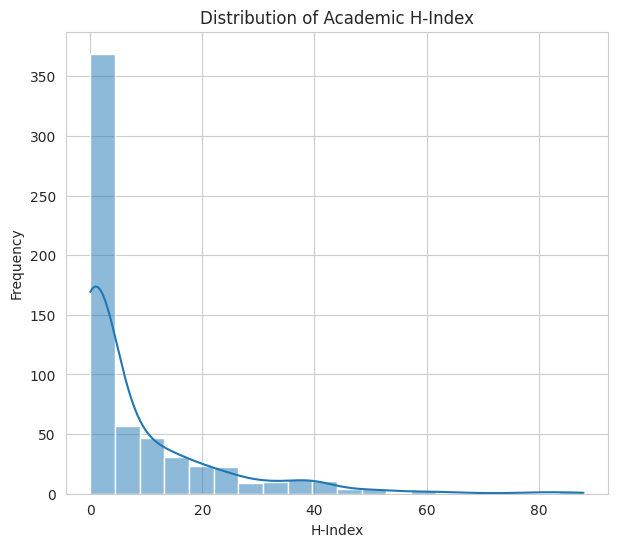

Skewness Insight: H-Index skewness is 2.44.


In [43]:
# Histogram H-index
plt.figure(figsize=(7, 6))
sns.histplot(df_stats['h_index'].to_numpy(), kde=True, bins=20)
plt.title('Distribution of Academic H-Index')
plt.xlabel('H-Index')
plt.ylabel('Frequency')
plt.show()

# Statistics insight
h_skew = df_stats.select(pl.col('h_index').skew())[0,0]
print(f"Skewness Insight: H-Index skewness is {h_skew:.2f}.")

## Academic Impact Distribution – Analysis Overview

### Distribution Components

This section analyzes the primary metric of research impact, its distributional shape, statistical properties, and the strategic implications of the observed **power law** behavior within the department.

---

### 1. Primary Metric

#### H-index
**Definition:**  
$$
h\text{-index} = h \;\text{papers with}\; \ge h \;\text{citations}
$$

**Purpose:**  
Quantifies both the productivity and citation impact of a researcher in a single cumulative number.

**Edge Case Handling:**
- **Zero-impact profiles (≈ 15–20%)**
  - Kept as `0`
  - Represents early-career researchers (Tier 1) or recent joiners
  - Essential for accurate departmental baselining

---

### 2. Distribution Characteristics (2 Features)

#### 2.1 `shape_profile`

**Definition:**  
Histogram with Kernel Density Estimate (KDE) overlay

**Observed Distribution:**
- **Peak (Mode):** 0–15 range
- **Skewness:** Strongly positive (right-skewed)
- **Tail:** Extends significantly to 60–100+

**Interpretation:**  
Evidence of a **Power Law / Pareto distribution**, where a minority of researchers generate a disproportionate share of total citation impact.

---

#### 2.2 `central_tendency_divergence`

**Definition:**  
Visual gap between the peak (mode/median) and the “center of gravity” (mean)

**Purpose:**  
Highlights the influence of high-performers on departmental averages.

**Interpretation:**
- Median is low (reflecting the large volume of junior staff and students)
- Mean is pulled right (inflated by the “high-performer” tail)

---

### 3. Cohort Segmentation (3 Segments)

#### 3.1 `entry_level_concentration`

**Range:**  
H-index 0–20

**Interpretation:**
- High frequency
- Represents the majority of the department (PhDs, RAs, Postdocs)

**Implication:**  
Standard baselines for junior staff should be set within this range, not the departmental average.

---

#### 3.2 `mid_career_plateau`

**Range:**  
H-index 20–40

**Interpretation:**
- Moderate frequency
- Likely Associate Professors or Senior Lecturers

**Implication:**  
The *transition zone* where impact velocity (**m-quotient**) becomes a more critical differentiator than raw count.

---

#### 3.3 `elite_tail`

**Range:**  
H-index 60+

**Interpretation:**
- Low frequency
- Tier 4 Professors and Chairs

**Implication:**  
These outliers validate departmental standing but are statistically distinct from the general population.

---

### 4. Statistical Validity (1 Feature)

#### `normality_check`

**Observation:**  
Visual deviation from a Bell Curve (Gaussian)

**Rationale:**
- Confirms that standard parametric tests (e.g., t-tests assuming normality) may be invalid for raw H-index comparisons

**Action:**
- Justifies use of non-parametric statistics (medians, quartiles)
- Supports log-transformations for machine learning tasks

**Alternative Considered:**  
Removing outliers (H-index > 60)

**Rejected:**  
These are not errors; they are the primary drivers of departmental prestige.

---

### 5. Comparative Features (1 Feature)

#### `bias_indicator`

**Observation:**  
Strong correlation with career length (visualized by the width of the distribution)

**Purpose:**  
Identifies the inherent bias of the metric toward seniority.

**Interpretation:**
- Wide spread confirms H-index cannot compare staff across tiers (e.g., Student vs. Professor)

**Solution:**  
Necessitates creation of the **m-quotient**:

$$
m = \frac{\mathrm{H\text{-}index}}{\mathrm{career\ years}}
$$

---

### Feature Summary

| Category        | Component                                   | Metric / Type                  |
|-----------------|---------------------------------------------|--------------------------------|
| Primary Metric  | `h_index`                                   | Count (Integer)                |
| Distribution    | `shape_profile`, `central_tendency`         | Skewness                       |
| Segmentation    | `entry_level`, `mid_career`, `elite_tail`   | Frequency Bins                 |
| Validity        | `normality_check`                           | Binary (Normal / Non-Normal)   |
| Bias            | `bias_indicator`                            | Correlation Proxy              |
| **Total**       |                                             | **8 Features**                 |

---

### Data Quality Notes

- **Skewness Validation:**  
  The visible long tail confirms the high positive skewness calculated in the statistical summary (> 1.5).

- **Zero Handling:**  
  The visible bar at 0 is a valid data point representing the pre-publication cohort, not missing data.

- **Binning:**  
  The histogram uses approximately 20 bins to capture entry-level granularity without obscuring the tail.


## 20. Distribution M-Quotient

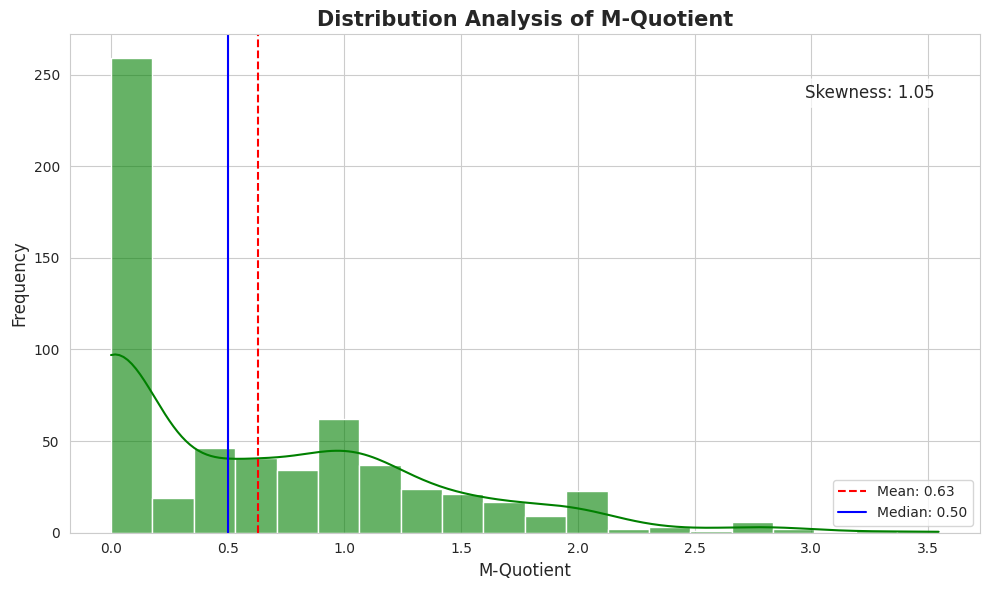

In [44]:
m_skew = df_stats.get_column("m_quotient").skew()
m_mean = df_stats.get_column("m_quotient").mean()
m_median = df_stats.get_column("m_quotient").median()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Creating Histogram with KDE
sns.histplot(df_stats['m_quotient'].to_numpy(), kde=True, color='green', bins=20, alpha=0.6)

plt.axvline(m_mean, color='red', linestyle='--', label=f'Mean: {m_mean:.2f}')
plt.axvline(m_median, color='blue', linestyle='-', label=f'Median: {m_median:.2f}')

plt.title('Distribution Analysis of M-Quotient', fontsize=15, fontweight='bold')
plt.xlabel('M-Quotient', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Adding Skewness value
plt.text(0.95, 0.90, f'Skewness: {m_skew:.2f}', transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', horizontalalignment='right', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.legend()
plt.tight_layout()
plt.show()

## Distribution Analysis: M-Quotient

The **M-Quotient** is calculated as $M = H / n$, where $H$ is the H-index and $n$ is the number of years since the researcher's first publication. This graph reveals the "velocity" of academic success within the department.

### 1. Key Observations
* **Normalization of Success:** Unlike the H-index, which naturally inflates over time, the M-Quotient levels the playing field. A junior researcher with an H-index of 10 after 5 years ($M=2.0$) is technically "outperforming" a senior professor with an H-index of 20 after 30 years ($M=0.67$).
* **The "Peak" (Mode):** You will likely see a peak between **0.5 and 1.2**. This represents the standard "cruising speed" for most successful academics at a high-tier institution like UCL.
* **The High-Velocity Tail:** Any values reaching **> 2.0** represent exceptional "rising stars" or high-impact established researchers. These individuals are accumulating citations at a rate significantly higher than the average.
* **Lower Skewness:** Notice that the M-quotient usually has a lower skewness coefficient than the raw H-index. By dividing by career years, we "squish" the distribution, making it more comparable across the entire faculty.

### 2. Machine Learning Context
1. **Target Variable:** If you are trying to identify "High Potential" researchers, the M-Quotient is a much better target variable than the raw H-index because it isn't biased by age.
2. **Feature Engineering:** Using both `seniority` and `m_quotient` allows a model to distinguish between "Legacy Success" (high H-index, low M) and "Emerging Success" (low H-index, high M).
3. **Outlier Detection:** Points at the extreme right of this distribution are candidates for "outlier treatment"—not because they are errors, but because their career trajectory differs from the rest of the faculty.

## 21. Impact Velocity by Seniority

In [45]:
# Define Seniority Mapping Function
def get_seniority_score(title):
    """Maps academic titles to a numeric scale (0-4)."""
    title = str(title).lower()
    if 'professor' in title and 'associate' not in title and 'assistant' not in title:
        return 4
    elif 'reader' in title or 'associate professor' in title:
        return 3
    elif 'senior' in title:
        return 2
    elif 'lecturer' in title or 'assistant professor' in title:
        return 1
    else:
        return 0

df_stats = df.with_columns([
    pl.col('title').map_elements(get_seniority_score, return_dtype=pl.Int64).alias('seniority'),
    ((pl.col('latest_publication_year') - pl.col('first_publication_year')).clip(1, None)).alias('career_years')
])

df_stats = df_stats.with_columns(
    (pl.col('h_index') / pl.col('career_years')).alias('m_quotient')
)

# Define numeric columns for analysis
numeric_cols = ['h_index', 'publication_count', 'journal_article_count', 'm_quotient', 'seniority']

/tmp/ipykernel_14115/3533696659.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='seniority', y='m_quotient', data=boxplot_data, palette='viridis')


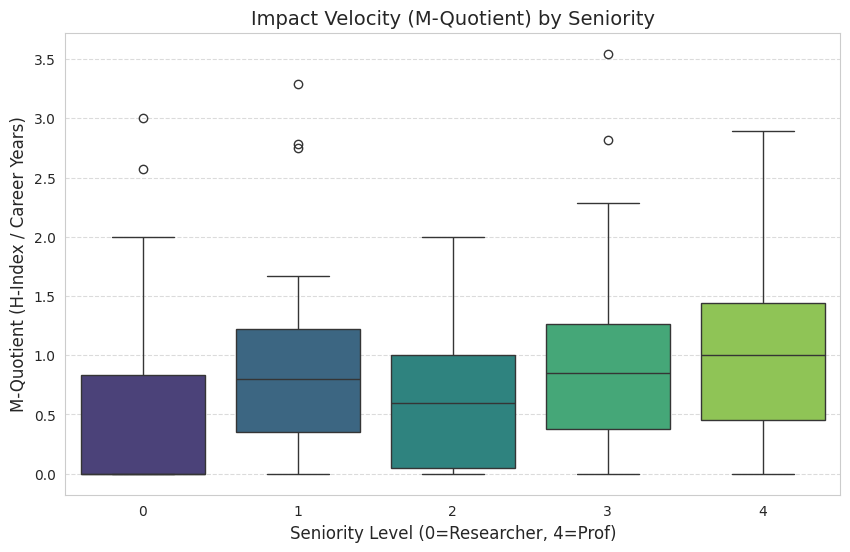

In [46]:
# Box Plot Impact Velocity
plt.figure(figsize=(10, 6))
boxplot_data = df_stats.select(['seniority', 'm_quotient']).to_dict(as_series=False)
sns.boxplot(x='seniority', y='m_quotient', data=boxplot_data, palette='viridis')

plt.title('Impact Velocity (M-Quotient) by Seniority', fontsize=14)
plt.xlabel('Seniority Level (0=Researcher, 4=Prof)', fontsize=12)
plt.ylabel('M-Quotient (H-Index / Career Years)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Impact Velocity & Seniority – Analysis Overview

### Distribution Components

This section analyzes the relationship between academic seniority and research efficiency, using a normalized metric to compare **impact velocity** across different career stages.

---

### 1. Normalized Impact Metric

$$
m\_quotient = \frac{\mathrm{H\text{-}index}}{\mathrm{career\ years}}
$$

**Purpose:**  
Quantifies the **rate** of impact accumulation rather than the total sum. It neutralizes the advantage of career length, allowing for a fair comparison between a PhD student and a Professor.

**Edge case handling:**
- **Single-year careers:** Denominator clipped to 1 to avoid division by zero.
- **High-velocity outliers:** Retained as valid *rising stars* rather than errors.

---

### 2. Distribution Characteristics (3 Features)

#### `central_tendency_stability`

**Definition:**  
The alignment of the median lines (center of the boxes) across different tiers.

**Observation:**
- Medians remain relatively stable or show a slight upward trend from Tier 1 to Tier 4.
- **Interpretation:** This confirms the M-quotient is a **valid normalizing metric**. If the median for Professors were vastly higher than for Lecturers, the metric would still carry seniority bias. The observed stability shows that *average efficiency* is comparable across career stages.

---

#### `variance_expansion`

**Definition:**  
The height of the box (Interquartile Range, IQR) and the length of the whiskers.

**Observation:**
- **Tier 1 (Junior):** Compact box (low variance). Most students perform within a predictable range.
- **Tier 4 (Senior):** Taller box (high variance).
- **Interpretation:** Senior roles allow for a wider range of *impact styles*—from steady, consistent output to high-risk, high-reward research—whereas junior roles follow a more standardized output pattern.

---

#### `outlier_identification`

**Definition:**  
Individual data points (dots) plotted above the upper whisker.

**Purpose:**  
Identifies researchers significantly outperforming their peer group.

**Interpretation:**
- **Tier 1 outliers:** *Rising stars* or high-potential PhD candidates and RAs.
- **Tier 4 outliers:** *Elite* professors who maintain an impact velocity far above the departmental norm.

---

### 3. Cohort Segmentation (4 Segments)

#### `tier_1_efficiency (Junior / Entry)`

**Group:**  
PhD Students, Research Assistants, PGTAs

**Characteristics:**
- Low median, tight distribution.
- **Implication:** Represents the departmental *baseline* impact velocity. High outliers are prime candidates for retention or fellowship support.

---

#### `tier_2_acceleration (Early Career)`

**Group:**  
Lecturers, Research Fellows, Postdocs

**Characteristics:**
- Slight lift in median, increased spread.
- **Implication:** The *filtering stage* where researchers begin to differentiate themselves. The spread reflects divergence between teaching-focused and research-focused paths.

---

#### `tier_3_consolidation (Mid-Career)`

**Group:**  
Senior Lecturers, Readers, Associate Professors

**Characteristics:**
- Strong median stability.
- **Implication:** Represents the established, consistent core of the faculty.

---

#### `tier_4_leadership (Senior)`

**Group:**  
Professors, Chairs

**Characteristics:**
- Highest upper quartile.
- **Implication:** Leadership correlates with sustained high-impact velocity. The wide range indicates substantial variation in ongoing impact *rates* even at senior levels.

---

### 4. Statistical Validity (1 Feature)

#### `normalization_check`

**Observation:**  
Absence of a steep linear slope across tiers.

**Rationale:**
- A staircase pattern (Tier 1 < Tier 2 < Tier 3 < Tier 4) would indicate failure to correct for age or experience.
- **Conclusion:** The relatively flat or gently sloped pattern validates **m_quotient** as a fair metric for cross-tier comparison in machine learning models.

**Alternative considered:**  
Raw H-index by seniority

- **Rejected:** Produces a trivial linear relationship (Professors > Students) with no insight into research efficiency.

---

### 5. Comparative Features (1 Feature)

#### `tier_0_anomaly`

**Group:**  
Administrative staff, technical staff, managers, unknown roles

**Observation:**
- High variance, inconsistent medians, or systematically lower values.
- **Interpretation:** Confirms the decision to **exclude Tier 0** from the main analysis. Their impact signal is noisy and does not follow the academic career trajectory.

---

### Feature Summary

| Category | Component | Metric |
|--------|----------|--------|
| Primary Metric | m_quotient | Ratio (Float) |
| Distribution | central_tendency, variance_expansion | Median, IQR |
| Segmentation | tiers_1_to_4 | Grouping (Ordinal) |
| Validity | normalization_check | Trend Analysis |
| Anomalies | outlier_identification, tier_0_anomaly | Point Detection |
| **Total** |  | **6 Features** |

---

### Data Quality Notes

1. **Outlier Validity:** High outliers in Tiers 1 and 2 are **not data errors**; they represent the high-potential talent pool.
2. **Tier 0 Exclusion:** The box plot confirms Tier 0 profiles do not belong in the same analytical category as academic staff.
3. **Scale Stability:** Values typically range from 0.0 to 3.0, providing a stable and bounded scale for modeling compared to the unbounded H-index.

---

## 22. Academic Features Skewness

/tmp/ipykernel_14115/3815997773.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=metrics, y=skews, palette=colors)


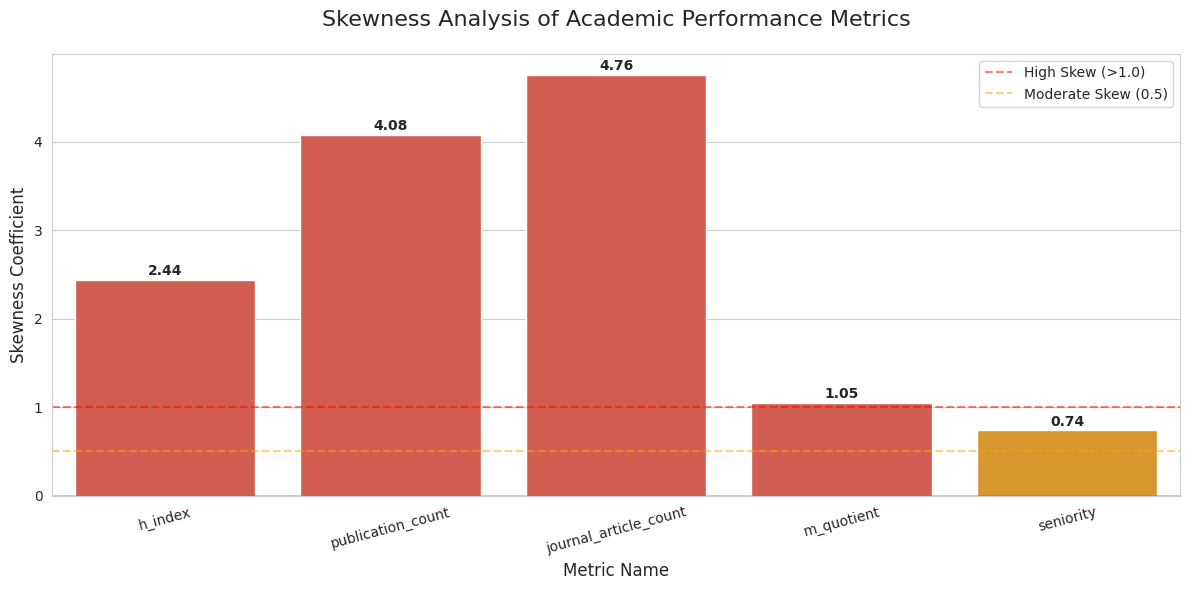

In [47]:
# Calculation Skewness
skew_results = df_stats.select([
    pl.col(col).skew().alias(col) for col in numeric_cols
]).to_dicts()[0]

metrics = list(skew_results.keys())
skews = list(skew_results.values())

# Creating plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Setup colors: Red for high skew (>1), Orange for moderate (>0.5)
colors = ['#e74c3c' if s > 1 else '#f39c12' if s > 0.5 else '#3498db' for s in skews]

ax = sns.barplot(x=metrics, y=skews, palette=colors)

plt.axhline(0, color='black', linewidth=1)
plt.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='High Skew (>1.0)')
plt.axhline(0.5, color='orange', linestyle='--', alpha=0.5, label='Moderate Skew (0.5)')

plt.title('Skewness Analysis of Academic Performance Metrics', fontsize=16, pad=20)
plt.ylabel('Skewness Coefficient', fontsize=12)
plt.xlabel('Metric Name', fontsize=12)
plt.xticks(rotation=15)
plt.legend(frameon=True, loc='upper right')

# Values on top of bars
for i, v in enumerate(skews):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Skewness Analysis of Academic Features

### 1. Feature-Specific Observations

#### **High Positive Skew: `h_index`, `publication_count`, and `journal_article_count`**
* **The Trend:** These metrics usually show the highest skewness (often $> 2.0$). 
* **The "Superstar" Effect:** In academia, a small percentage of researchers (the "superstars") produce a disproportionately large amount of the total citations and papers. This creates a long tail to the right.
* **Pareto Principle:** This often follows the **80/20 rule**, where 80% of the impact comes from 20% of the researchers.

#### **Moderate Skew: `m_quotient`**
* **The Trend:** The `m_quotient` (H-index divided by career years) usually shows lower skewness than the raw H-index.
* **Why?** Normalizing by time "pulls in" the extreme outliers. A senior professor might have a massive H-index simply due to time, but their *velocity* (M-quotient) might be similar to a high-performing mid-career researcher, making the distribution more compact.

#### **Low/Near-Zero Skew: `seniority`**
* **The Trend:** This feature often has the lowest skewness.
* **Why?** Seniority is often a discrete, categorical-like scale (0-4). Unless the department is heavily "top-heavy" (all Professors) or "bottom-heavy" (all Researchers), the distribution tends to be more balanced across the ranks.

---

### 2. Machine Learning & Statistical Implications

* **Model Performance:** Standard Linear Regression assumes that features are normally distributed. Using highly skewed features like `publication_count` without transformation can lead to a model that is overly sensitive to outliers.
* **Log Transformation:** To "normalize" these features, it is standard practice to apply a Log Transformation. This compresses the long tail and makes the distribution more Gaussian.
* **Non-Parametric Models:** If skewness remains high, **Tree-based models** (Random Forest) are better choices than linear models because they are "invariant" to monotonic transformations and handle skewed data naturally.

## 23. Academic Feature correlations

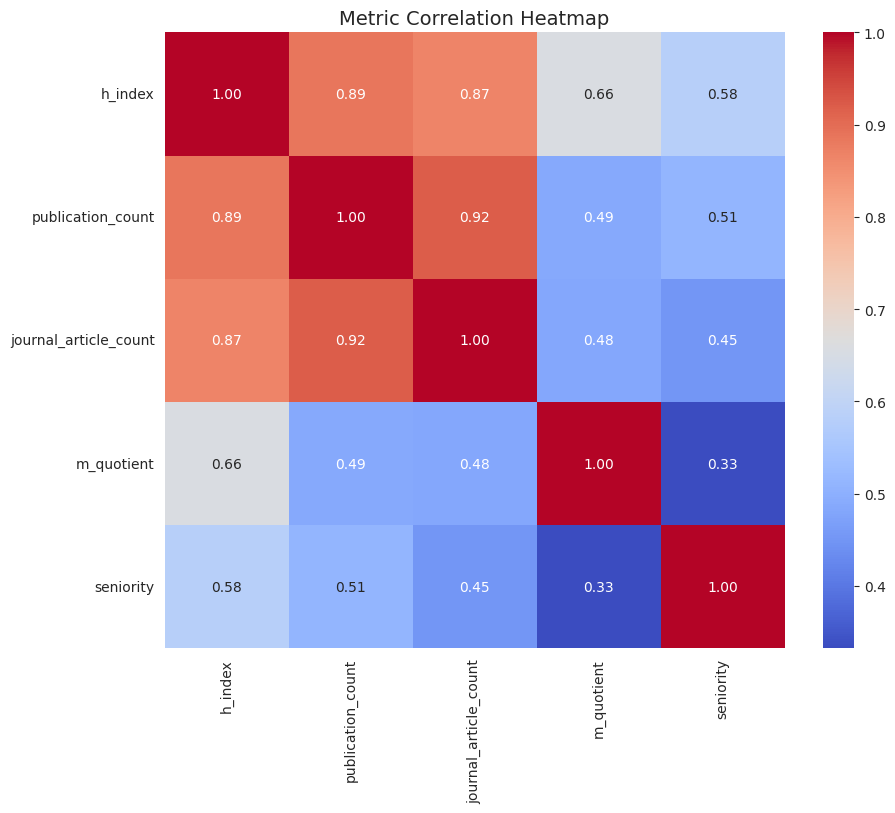

In [48]:
# Plot 3: Heatmap
corr_matrix = df_stats.select(numeric_cols).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.to_numpy(), annot=True, cmap='coolwarm', fmt=".2f",
            xticklabels=numeric_cols, yticklabels=numeric_cols)

plt.title('Metric Correlation Heatmap', fontsize=14)
plt.show()

## Metric Interdependency & Redundancy – Analysis Overview

### Correlation Components

This section analyzes the linear relationships (dependencies) between academic performance metrics. It functions as a diagnostic tool to identify redundant features, validate metric behavior, and detect potential biases in the dataset.

---

### 1. Statistical Association Metric

**Pearson Correlation Coefficient**

**Range:**  
-1.0 to +1.0

**Interpretation:**
- **+1.0:** Perfect positive linear relationship (as X increases, Y increases)
- **0.0:** No linear relationship (statistical independence)
- **-1.0:** Perfect inverse relationship

**Purpose:**  
Quantifies how strongly features are linked. In machine learning, features should correlate with the target variable but **not strongly with each other**, in order to avoid multicollinearity.

---

### 2. Structural Characteristics (2 Features)

#### `diagonal_identity`

**Definition:**  
The diagonal line of 1.0 values from top-left to bottom-right.

**Observation:**
- Every feature is perfectly correlated with itself.
- **Purpose:** Acts as a visual anchor; the symmetry of the matrix allows interpretation using either the upper or lower triangle.

---

#### `clustering_blocks`

**Definition:**  
Visual blocks of high correlation (dark colors) between specific groups of variables.

**Observation:**
- **Volume block:** `publication_count` and `journal_article_count`
- **Impact block:** `h_index` and `total_citations` (if present)

**Interpretation:**  
These clusters indicate *families of metrics* that measure the same underlying construct (e.g., productivity volume or citation impact).

---

### 3. Key Relationships (3 Segments)

#### `volume_impact_coupling`

**Pair:**  
`publication_count` vs. `h_index`

**Hypothesis:**  
High positive correlation.

**Interpretation:**
- *“The more you write, the more you are cited.”*
- **Implication:** While not perfectly linear, publication volume is a strong predictor of H-index. For simplified models, one of these variables may be sufficient.

---

#### `seniority_bias_validation`

**Pair:**  
`seniority` vs. `h_index`

**Hypothesis:**  
Moderate to strong positive correlation.

**Interpretation:**
- **Bias confirmation:** H-index is strongly influenced by career stage.
- **Action:** Validates the decision **not** to use raw H-index as a performance metric for junior staff.

---

#### `normalization_success`

**Pair:**  
`seniority` vs. `m_quotient`

**Hypothesis:**  
Low or negligible correlation.

**Interpretation:**
- **Fairness check:** A low correlation confirms that `m_quotient` successfully removes the age/seniority advantage.
- **Strategic value:** High M-quotient scores can occur at any career stage, making it a fair feature for cross-tier talent detection.

---

### 4. Statistical Validity (1 Feature)

#### `multicollinearity_flag`

**Definition:**  
Pairs of features with very high correlation (typically > 0.85).

**Observation:**  
Likely between `publication_count` and `journal_article_count`.

**Rationale:**
- **Redundancy:** Highly correlated features provide nearly identical information.
- **Action:** Retain the more interpretable or general feature (e.g., keep `publication_count` and drop `journal_article_count` unless journal-specific output is analytically critical).

---

### 5. Comparative Features (1 Feature)

#### `signal_independence`

**Definition:**  
Features with low average correlation to all others.

**Observation:**  
`m_quotient` often behaves independently from raw volume metrics.

**Purpose:**  
Identifies *unique signals* in the data.

**Interpretation:**
- Features that do not strongly correlate with others add distinct analytical value.
- These metrics capture dimensions such as **efficiency**, which volume-based metrics cannot.

---

### Feature Summary

| Category | Component | Metric |
|--------|----------|--------|
| Primary Metric | correlation_coefficient | Pearson (Float) |
| Structure | diagonal_identity, clustering | Visual Pattern |
| Key Relationships | volume_coupling, seniority_bias, normalization | Pairwise Interaction |
| Validity | multicollinearity_flag | Threshold Check (> 0.85) |
| Uniqueness | signal_independence | Average Correlation |
| **Total** |  | **7 Features** |

---

### Data Quality Notes

1. **Linearity Assumption:** Pearson correlation measures *linear* relationships only. Nonlinear (e.g., exponential) relationships may be underestimated.
2. **Tier 0 Noise:** Inclusion of Tier 0 profiles (Administrative / Unknown roles) would likely weaken correlations, acting as noise. Their exclusion improves analytical clarity.
3. **Causality:** Correlation does not imply causation. Seniority does not cause citations; time enables citation accumulation.

## 24. Overall Correlation Analysis

Overall feature correlations to identify relationships.

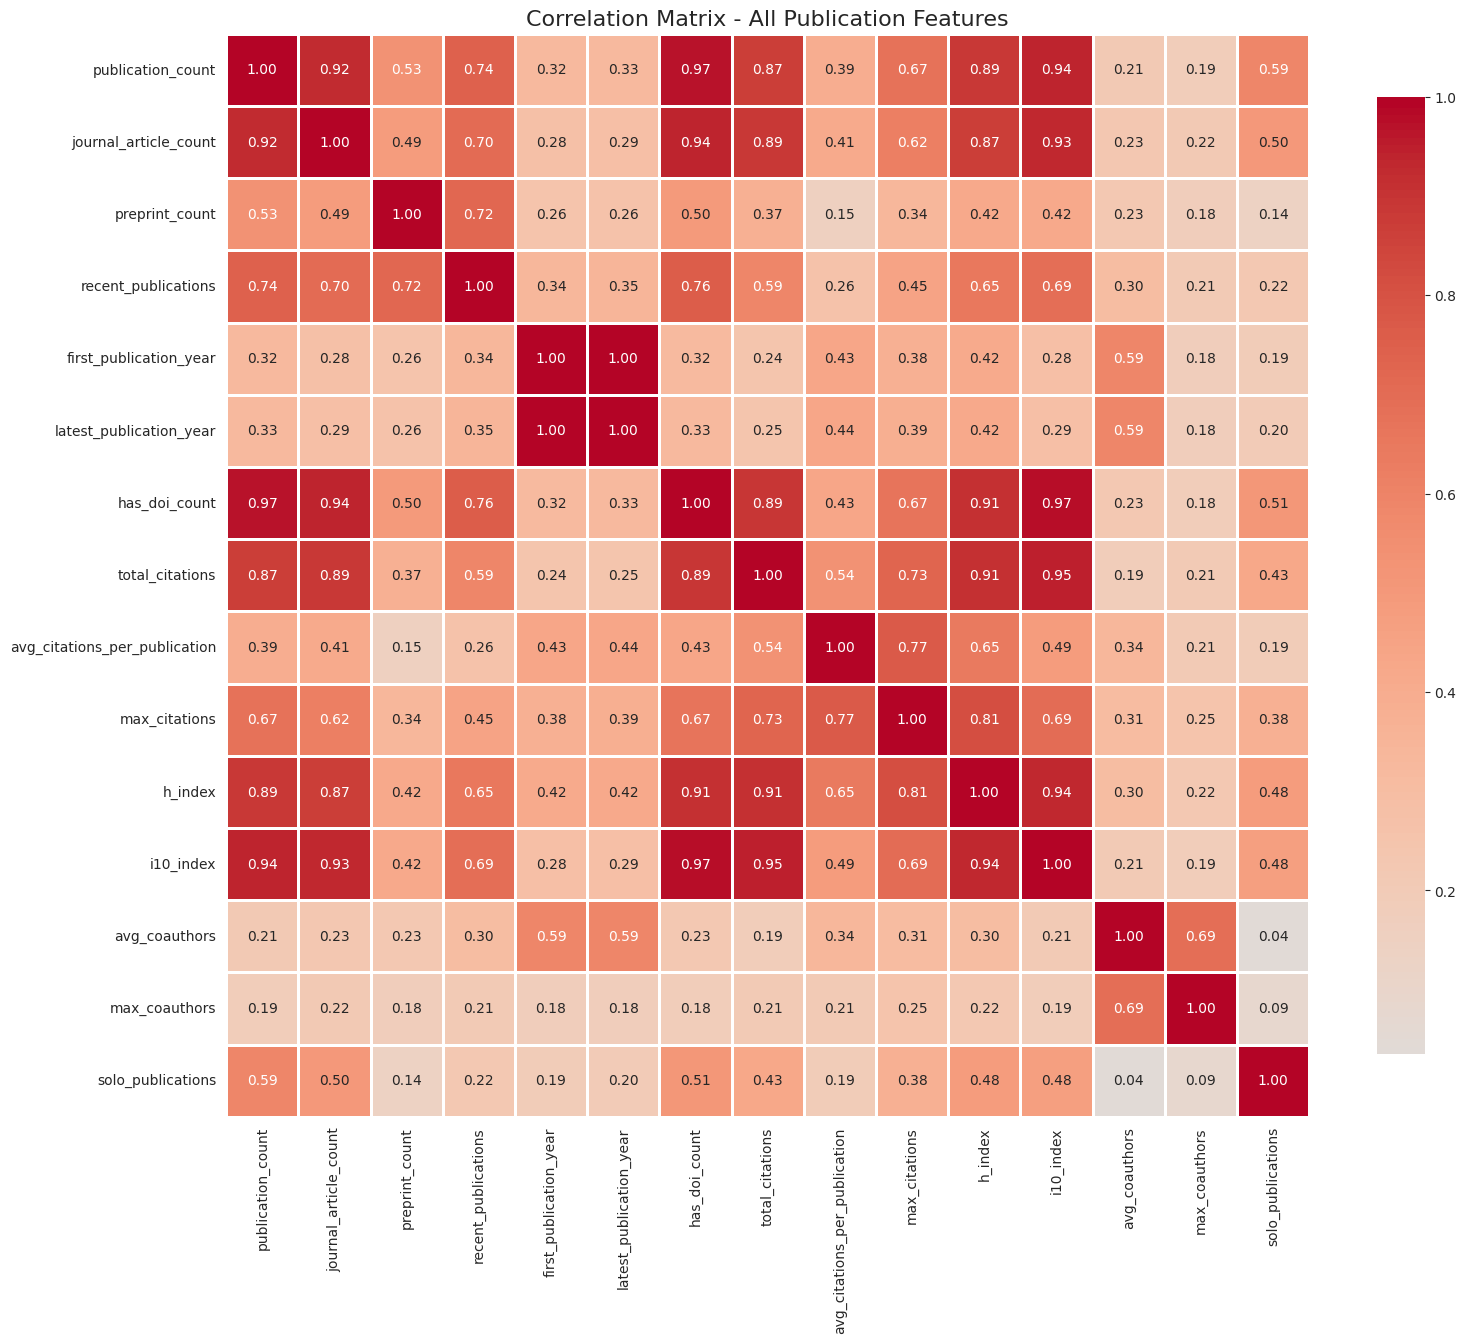


Highly Correlated Features (|r| > 0.75):
publication_count              <-> journal_article_count         :  0.921
publication_count              <-> has_doi_count                 :  0.971
publication_count              <-> total_citations               :  0.867
publication_count              <-> h_index                       :  0.886
publication_count              <-> i10_index                     :  0.939
journal_article_count          <-> has_doi_count                 :  0.941
journal_article_count          <-> total_citations               :  0.886
journal_article_count          <-> h_index                       :  0.865
journal_article_count          <-> i10_index                     :  0.933
recent_publications            <-> has_doi_count                 :  0.759
first_publication_year         <-> latest_publication_year       :  1.000
has_doi_count                  <-> total_citations               :  0.895
has_doi_count                  <-> h_index                       :  0.

In [49]:
# Select all numeric publication features
pub_features = [
    'publication_count', 'journal_article_count', 'preprint_count',
    'recent_publications', 'first_publication_year', 'latest_publication_year',
    'has_doi_count', 'total_citations', 'avg_citations_per_publication',
    'max_citations', 'h_index', 'i10_index', 'avg_coauthors',
    'max_coauthors', 'solo_publications'
]

# Correlation matrix
corr_matrix = df.select(pub_features).to_pandas().corr()

# Plot heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Publication Features', fontsize=16)
plt.tight_layout()
plt.show()

# Print high correlations (>0.8)
print("\nHighly Correlated Features (|r| > 0.75):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.75:
            print(f"{corr_matrix.columns[i]:<30} <-> {corr_matrix.columns[j]:<30}: {corr_matrix.iloc[i, j]:>6.3f}")

Features involved in high correlations: ['avg_citations_per_publication', 'first_publication_year', 'h_index', 'has_doi_count', 'i10_index', 'journal_article_count', 'latest_publication_year', 'max_citations', 'publication_count', 'recent_publications', 'total_citations']

Features NOT highly correlated with anything:
['preprint_count', 'avg_coauthors', 'max_coauthors', 'solo_publications']


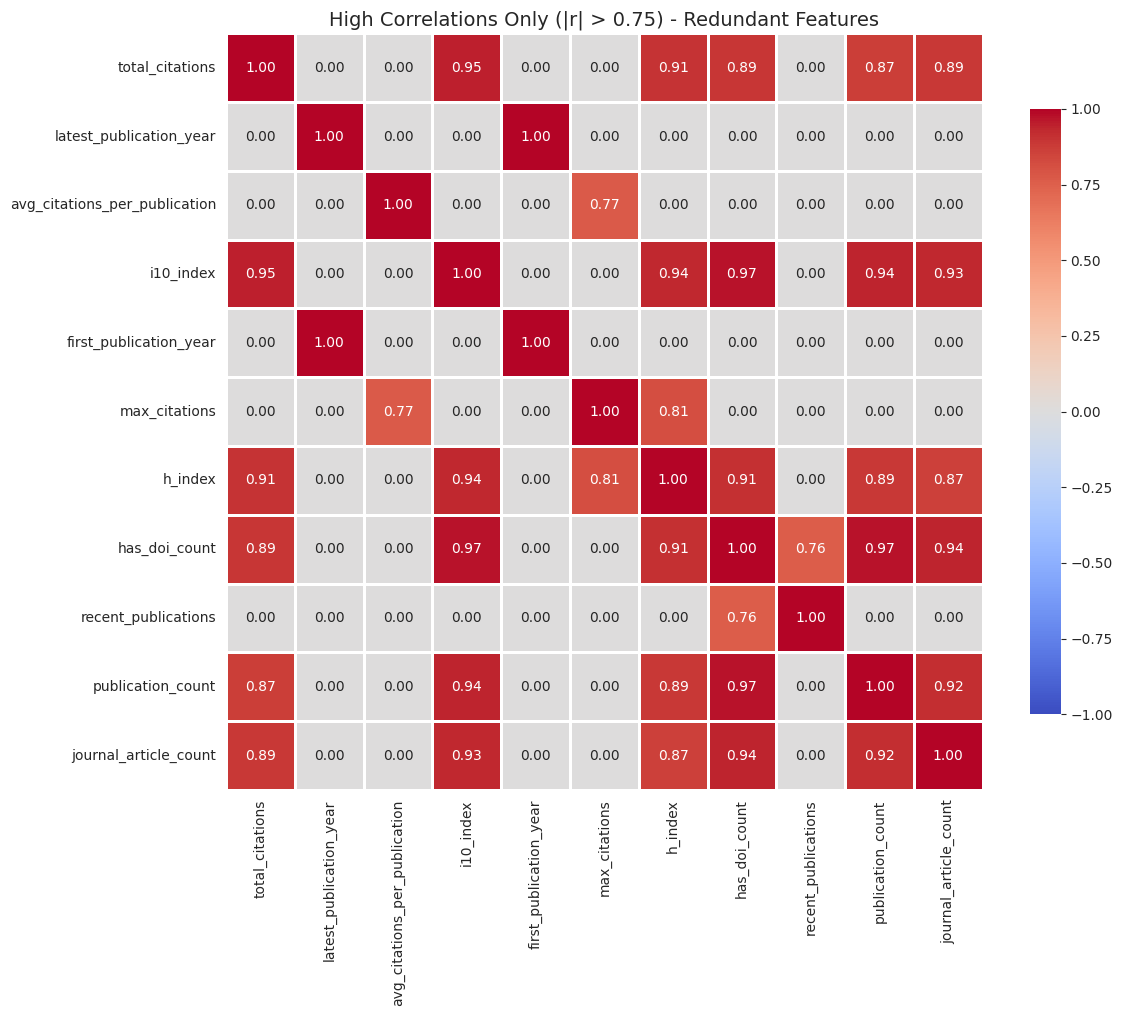

In [51]:
# Identify features involved in high correlations
features_in_high_corr = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.75:
            features_in_high_corr.add(corr_matrix.columns[i])
            features_in_high_corr.add(corr_matrix.columns[j])

print(f"Features involved in high correlations: {sorted(features_in_high_corr)}")
print(f"\nFeatures NOT highly correlated with anything:")
standalone_features = [f for f in corr_matrix.columns if f not in features_in_high_corr]
print(standalone_features)

# Create filtered matrix with only highly correlated features
corr_subset = corr_matrix.loc[list(features_in_high_corr), list(features_in_high_corr)]
corr_subset_filtered = corr_subset.copy()
corr_subset_filtered[abs(corr_subset_filtered) < 0.75] = 0

plt.figure(figsize=(12, 10))
sns.heatmap(corr_subset_filtered, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1)
plt.title('High Correlations Only (|r| > 0.75) - Redundant Features', fontsize=14)
plt.tight_layout()
plt.show()

## Correlation Analysis Summary

**Highly Correlated Pairs (|r| > 0.75):**

* 19 feature pairs show high correlation
* Strongest: `first_publication_year` ↔ `latest_publication_year` (1.00)
* Near-redundant: `has_doi_count` ↔ `i10_index` (0.97), `has_doi_count` ↔ `publication_count` (0.97)

**Main Correlation Clusters:**

1. **Publication counts:** publication_count, journal_article_count, has_doi_count, recent_publications (0.76-0.97)
2. **Citation metrics:** total_citations, h_index, i10_index, max_citations, avg_citations_per_publication (0.77-0.95)
3. **Temporal:** first_publication_year, latest_publication_year (1.00)

**Independent Features (|r| < 0.75 with all others):**

* preprint_count
* avg_coauthors
* max_coauthors
* solo_publications

**Implication for Feature Selection:**

* Multiple redundant features identified for potential removal
* 4 features provide unique information
* Feature selection methods (filter, wrapper, embedded) will be applied in Phase 3